# Segunda entrega trabajo integrador

## Analisis exploratorio de datos

In [33]:
import pandas as pd

df = pd.read_csv('data.csv')
df.head()

,date,text,favorites,retweets,Toxic,Insult,Profanity,Derogatory,Sexual,"Death, Harm & Tragedy",...,Illicit Drugs,War & Conflict,Politics,Finance,Legal,btc_tweet_day,btc_24h_after,btc_48h_after,btc_delta_24h,btc_delta_48h
0,2020-03-03 01:34:00,I was thrilled to be back in the Great city of...,73748,17404,0.014622,0.010394,0.002904,0.003574,0.002435,0.059701,...,0.036585,0.472222,0.867769,0.079710,0.435185,8753.01,8700.00,9085.48,-53.01,332.47
1,2020-01-17 03:22:00,RT @CBS_Herridge: READ: Letter to surveillance...,0,7396,0.050346,0.050961,0.023985,0.008934,0.010127,0.085399,...,0.294118,0.350000,0.680934,0.081967,0.948357,8850.83,8903.26,8631.95,52.43,-218.88
2,2020-09-12 20:10:00,The Unsolicited Mail In Ballot Scam is a major...,80527,23502,0.258527,0.112138,0.058611,0.043741,0.015008,0.082609,...,0.700000,0.058824,0.937500,0.515901,0.858108,10359.99,10280.14,10698.03,-79.85,338.04
3,2020-01-17 13:13:00,RT @MZHemingway: Very friendly telling of even...,0,9081,0.018771,0.012035,0.004276,0.003942,0.002470,0.207207,...,0.057377,0.375000,0.912500,0.079710,0.333333,8850.83,8903.26,8631.95,52.43,-218.88
4,2020-01-17 00:11:00,RT @WhiteHouse: President @realDonaldTrump ann...,0,25048,0.016713,0.011194,0.004276,0.005187,0.002435,0.073482,...,0.057377,0.141892,0.969512,0.102302,0.948357,8850.83,8903.26,8631.95,52.43,-218.88


In [34]:
# Agregar features de cambio porcentual
# Calcular el cambio porcentual de 24h y 48h vs el precio del día del tweet
df['btc_delta_24h_pct'] = df['btc_delta_24h'] / df['btc_tweet_day']
df['btc_delta_48h_pct'] = df['btc_delta_48h'] / df['btc_tweet_day']

# Verificar los nuevos features
print(f"btc_delta_24h_pct: min={df['btc_delta_24h_pct'].min():.4f}, max={df['btc_delta_24h_pct'].max():.4f}")
print(f"btc_delta_48h_pct: min={df['btc_delta_48h_pct'].min():.4f}, max={df['btc_delta_48h_pct'].max():.4f}")

df[['btc_tweet_day', 'btc_delta_24h', 'btc_delta_48h', 'btc_delta_24h_pct', 'btc_delta_48h_pct']].head()


btc_delta_24h_pct: min=-0.2287, max=0.2680
btc_delta_48h_pct: min=-0.3404, max=0.2413


,btc_tweet_day,btc_delta_24h,btc_delta_48h,btc_delta_24h_pct,btc_delta_48h_pct
0,8753.01,-53.01,332.47,-0.006056,0.037984
1,8850.83,52.43,-218.88,0.005924,-0.024730
2,10359.99,-79.85,338.04,-0.007708,0.032629
3,8850.83,52.43,-218.88,0.005924,-0.024730
4,8850.83,52.43,-218.88,0.005924,-0.024730


Vamos a comenzar acomodando las columnas generadas por la herramienta de analisis de Google, normlaizandolas\

Para eso se normaliza re escalando contra el maximo del valor de la columna

In [35]:
# Convertir todas las columnas a lowercase snake_case
import re

def to_snake_case(name):
    """Convierte un string a snake_case"""
    # Insertar un guión bajo antes de cualquier letra mayúscula que esté precedida por una letra minúscula
    s1 = re.sub('(.)([A-Z][a-z]+)', r'\1_\2', name)
    # Insertar un guión bajo antes de cualquier letra mayúscula que esté precedida por una letra minúscula o dígito
    s2 = re.sub('([a-z0-9])([A-Z])', r'\1_\2', s1)
    # Convertir a minúsculas y reemplazar espacios y guiones con guiones bajos
    s3 = re.sub(r'[-\s]+', '_', s2)
    # Limpiar guiones bajos múltiples
    s4 = re.sub(r'_+', '_', s3)
    # Remover guiones bajos al inicio y final
    return s4.strip('_').lower()


# Convertir a snake_case
df.columns = [to_snake_case(col) for col in df.columns]


In [36]:
from sklearn.preprocessing import MinMaxScaler

# Google columns to rescale
columns_to_rescale = [
    'toxic', 'insult', 'profanity', 'derogatory', 'sexual', 
    'death,_harm_&_tragedy', 'violent', 'firearms_&_weapons', 
    'public_safety', 'health', 'religion_&_belief', 'illicit_drugs', 
    'war_&_conflict', 'politics', 'finance', 'legal'
]

# Filtrar solo las columnas que existen
existing_columns = [col for col in columns_to_rescale if col in df.columns]

# Aplicar MinMaxScaler directamente al DataFrame original
scaler = MinMaxScaler(feature_range=(0, 1))
df[existing_columns] = scaler.fit_transform(df[existing_columns])

df[existing_columns].head()


,toxic,insult,profanity,derogatory,sexual,"death,_harm_&_tragedy",violent,firearms_&_weapons,public_safety,health,religion_&_belief,illicit_drugs,war_&_conflict,politics,finance,legal
0,0.004080,0.004846,0.003078,0.005484,0.003537,0.059701,0.016369,0.018182,0.051813,0.023788,0.053924,0.036585,0.472222,0.867769,0.079770,0.435185
1,0.043941,0.052683,0.025424,0.013710,0.015471,0.085399,0.777035,0.105263,0.976744,0.102968,0.019229,0.294118,0.350000,0.680934,0.082029,0.948357
2,0.276231,0.124824,0.062128,0.067121,0.023045,0.082609,0.238746,0.105263,0.594771,0.102968,0.101176,0.700000,0.058824,0.937500,0.516288,0.858108
3,0.008710,0.006781,0.004532,0.006049,0.003591,0.207207,0.195894,0.018182,0.594771,0.034775,0.053924,0.057377,0.375000,0.912500,0.079770,0.333333
4,0.006414,0.005790,0.004532,0.007959,0.003537,0.073482,0.187486,0.076923,0.090909,0.096141,0.927211,0.057377,0.141892,0.969512,0.102379,0.948357


## En busca de correlaciones

In [37]:
# Función para generar scatter plots de variables Google vs BTC deltas porcentuales
import matplotlib.pyplot as plt
def plot_google_vs_btc_deltas(column_name, title_name=None):
    """
    Genera scatter plots de una variable Google vs los deltas porcentuales de BTC
    
    Parameters:
    column_name (str): Nombre de la columna de la variable Google
    title_name (str): Nombre para mostrar en el título (opcional, usa column_name si no se proporciona)
    """
    if title_name is None:
        title_name = column_name.replace('_', ' ').title()
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Scatter plot vs BTC delta 24h porcentual
    ax1.scatter(df[column_name], df['btc_delta_24h_pct'], alpha=0.6)
    ax1.set_xlabel(title_name)
    ax1.set_ylabel('BTC Delta 24h (%)')
    ax1.set_title(f'{title_name} vs BTC Delta 24h (%)')
    ax1.grid(True, alpha=0.3)
    
    # Scatter plot vs BTC delta 48h porcentual
    ax2.scatter(df[column_name], df['btc_delta_48h_pct'], alpha=0.6)
    ax2.set_xlabel(title_name)
    ax2.set_ylabel('BTC Delta 48h (%)')
    ax2.set_title(f'{title_name} vs BTC Delta 48h (%)')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


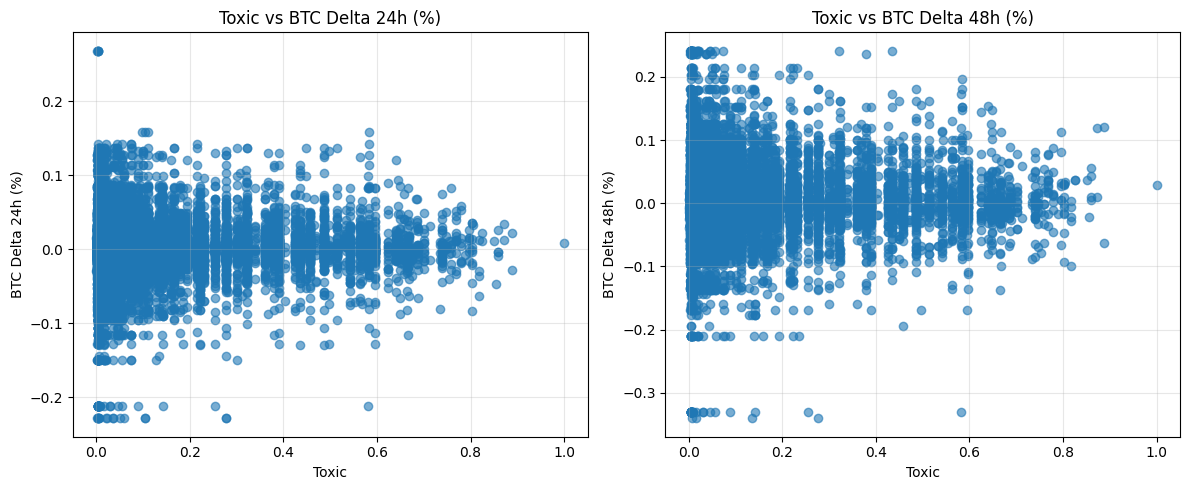

In [38]:
# Scatter plot: toxic vs BTC deltas
plot_google_vs_btc_deltas('toxic')


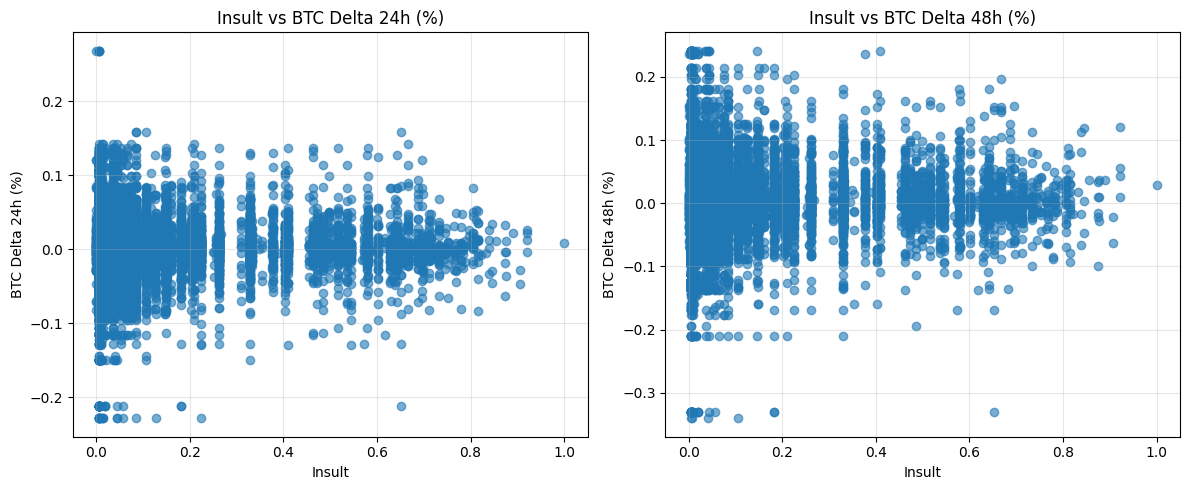

In [39]:
# Scatter plot: insult vs BTC deltas
plot_google_vs_btc_deltas('insult')


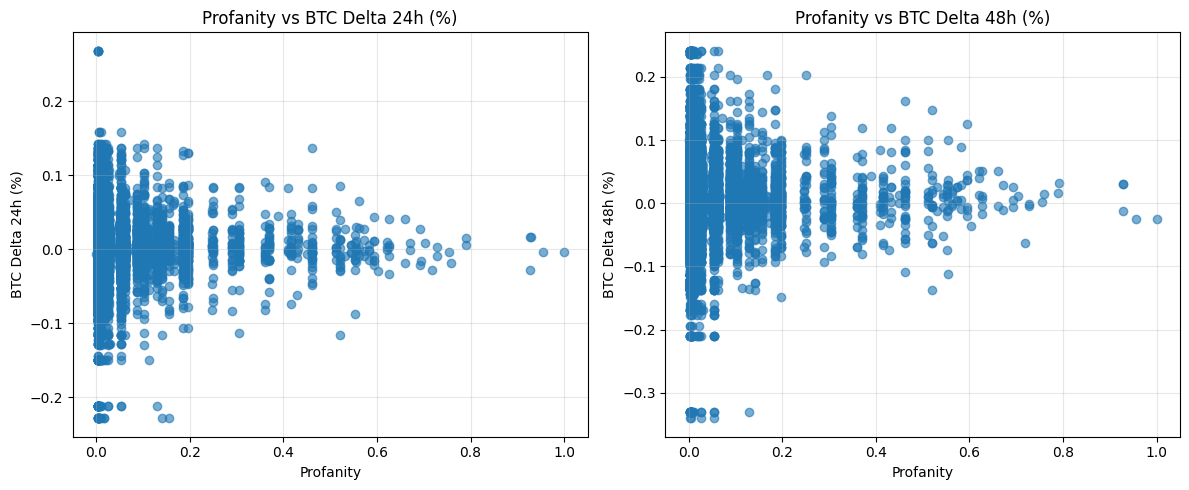

In [40]:
# Scatter plot: profanity vs BTC deltas
plot_google_vs_btc_deltas('profanity')


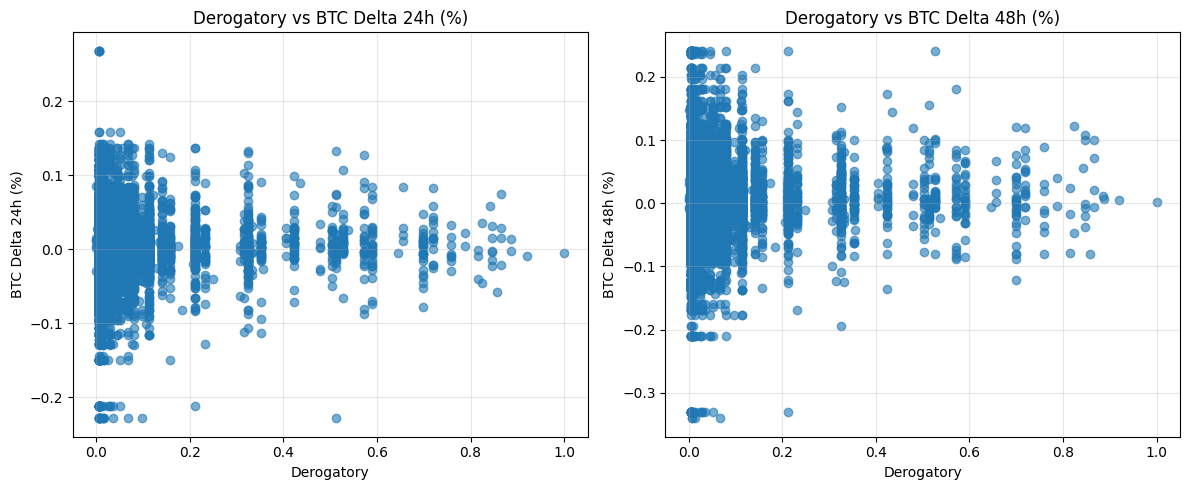

In [41]:
# Scatter plot: derogatory vs BTC deltas
plot_google_vs_btc_deltas('derogatory')


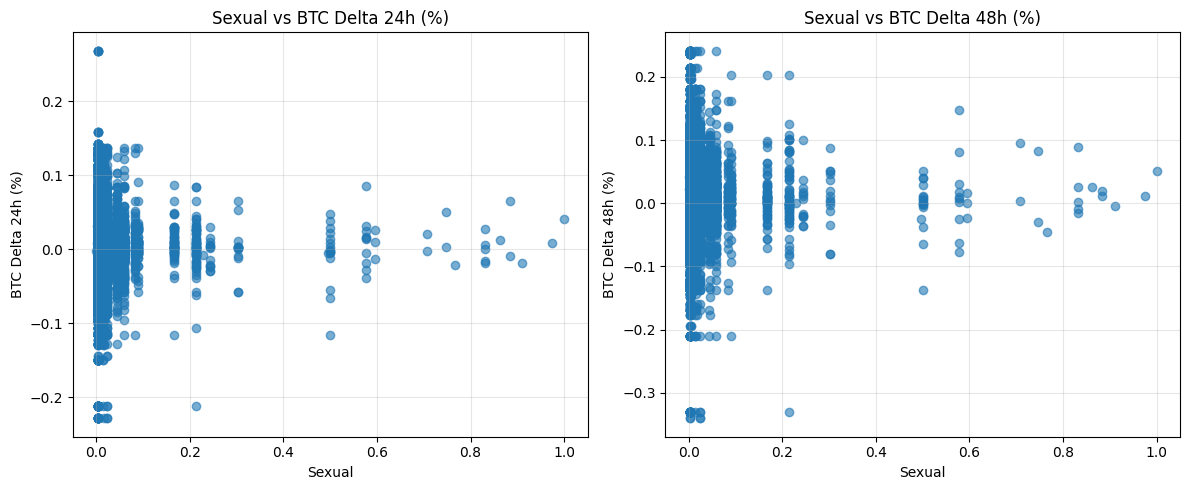

In [42]:
# Scatter plot: sexual vs BTC deltas
plot_google_vs_btc_deltas('sexual')


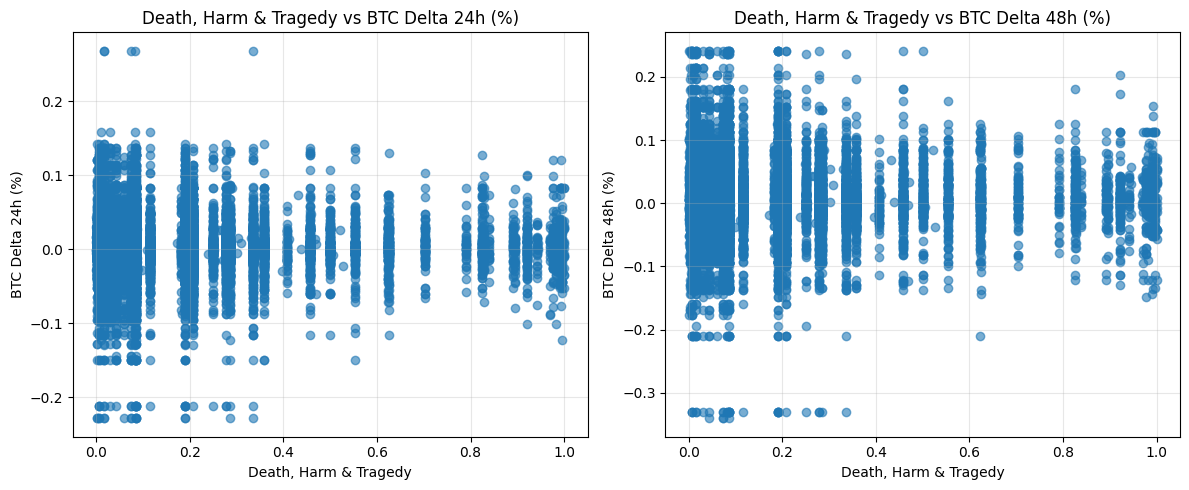

In [43]:
# Scatter plot: death,_harm_&_tragedy vs BTC deltas
plot_google_vs_btc_deltas('death,_harm_&_tragedy', 'Death, Harm & Tragedy')


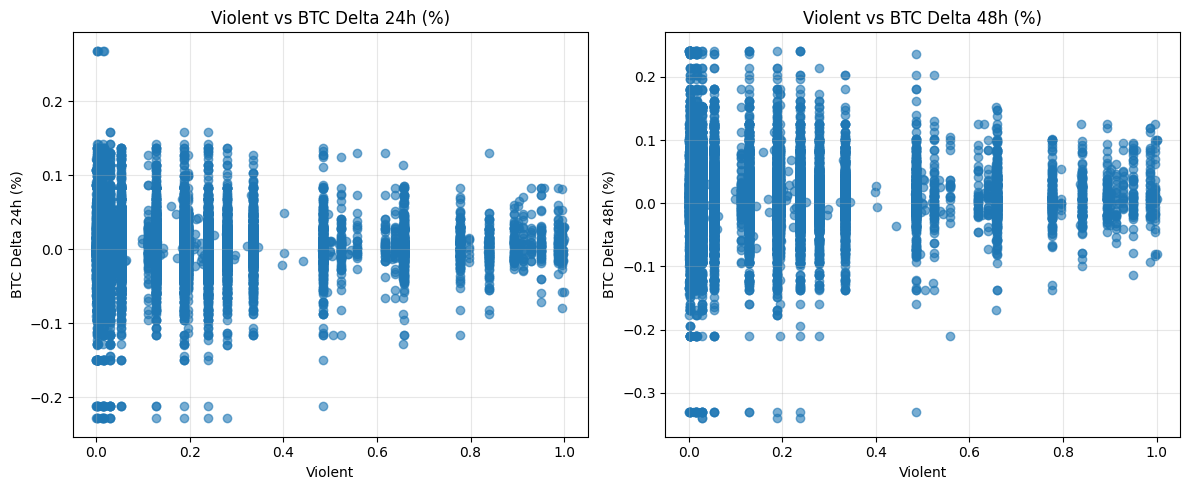

In [44]:
# Scatter plot: violent vs BTC deltas
plot_google_vs_btc_deltas('violent')


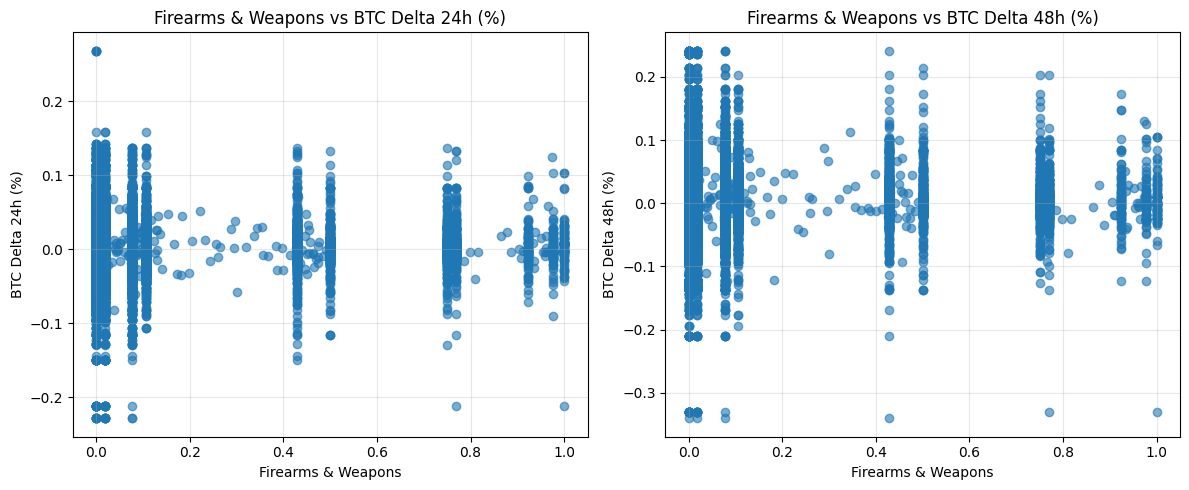

In [45]:
# Scatter plot: firearms_&_weapons vs BTC deltas
plot_google_vs_btc_deltas('firearms_&_weapons', 'Firearms & Weapons')


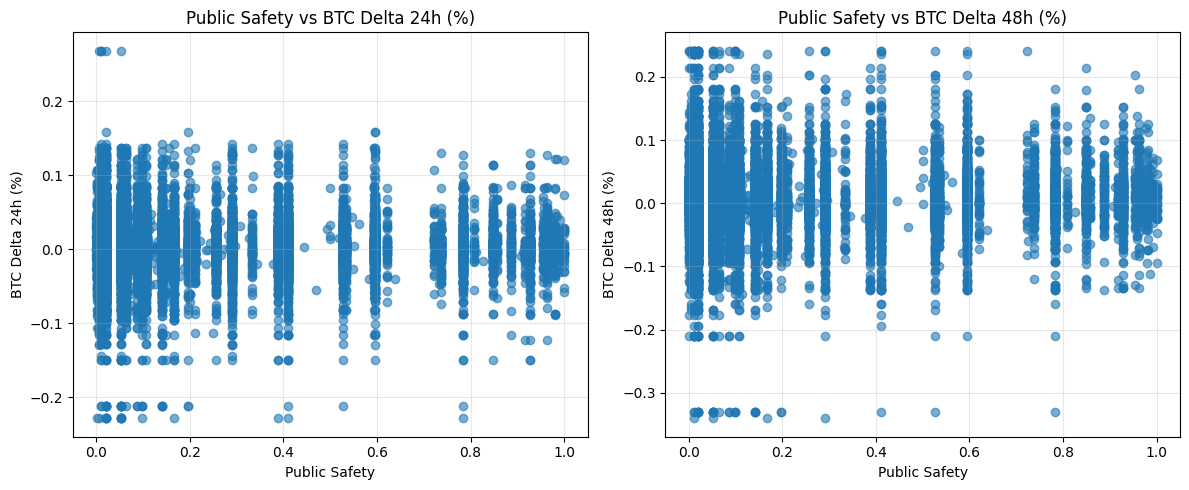

In [46]:
# Scatter plot: public_safety vs BTC deltas
plot_google_vs_btc_deltas('public_safety', 'Public Safety')


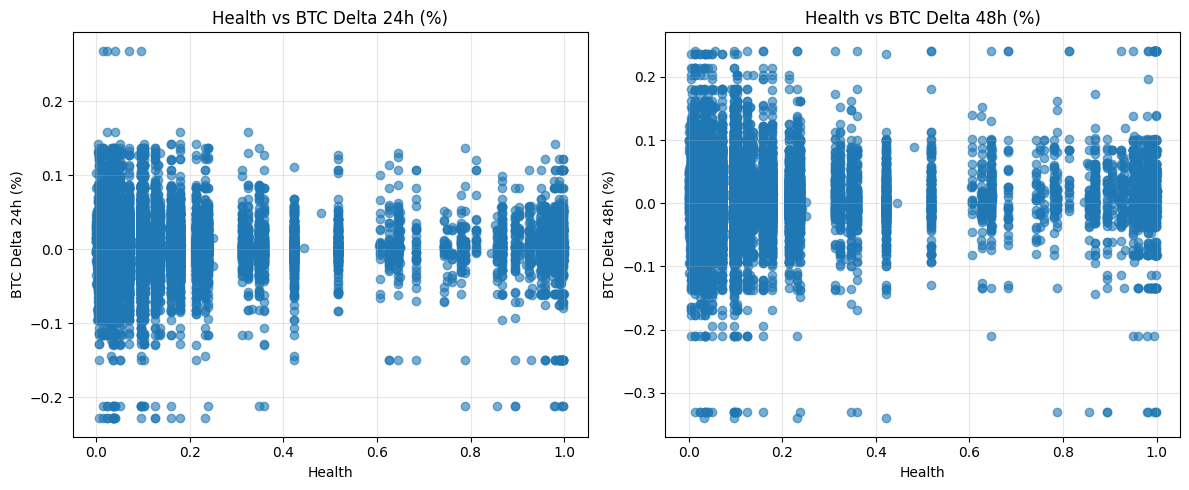

In [47]:
# Scatter plot: health vs BTC deltas
plot_google_vs_btc_deltas('health')


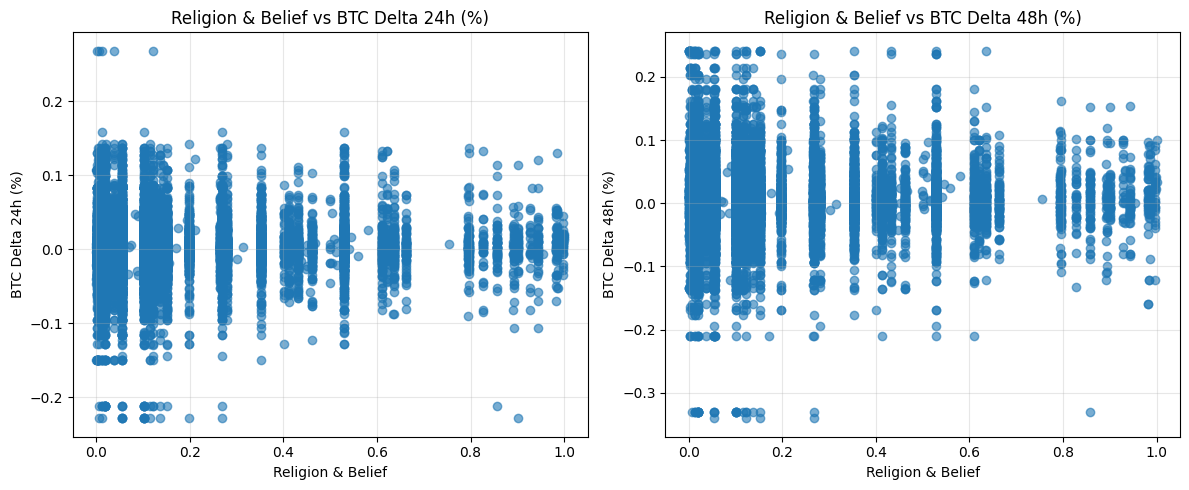

In [48]:
# Scatter plot: religion_&_belief vs BTC deltas
plot_google_vs_btc_deltas('religion_&_belief', 'Religion & Belief')


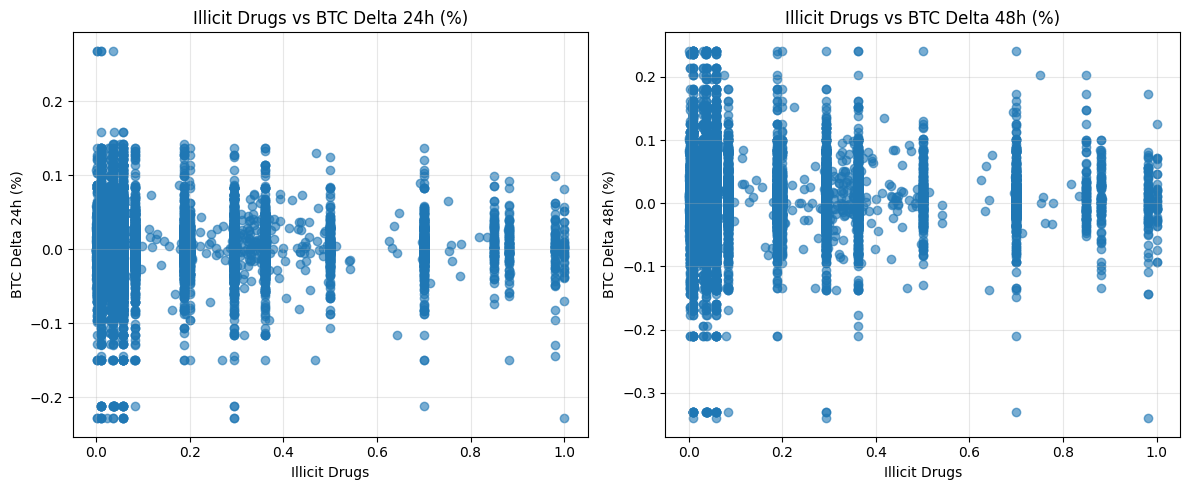

In [49]:
# Scatter plot: illicit_drugs vs BTC deltas
plot_google_vs_btc_deltas('illicit_drugs', 'Illicit Drugs')


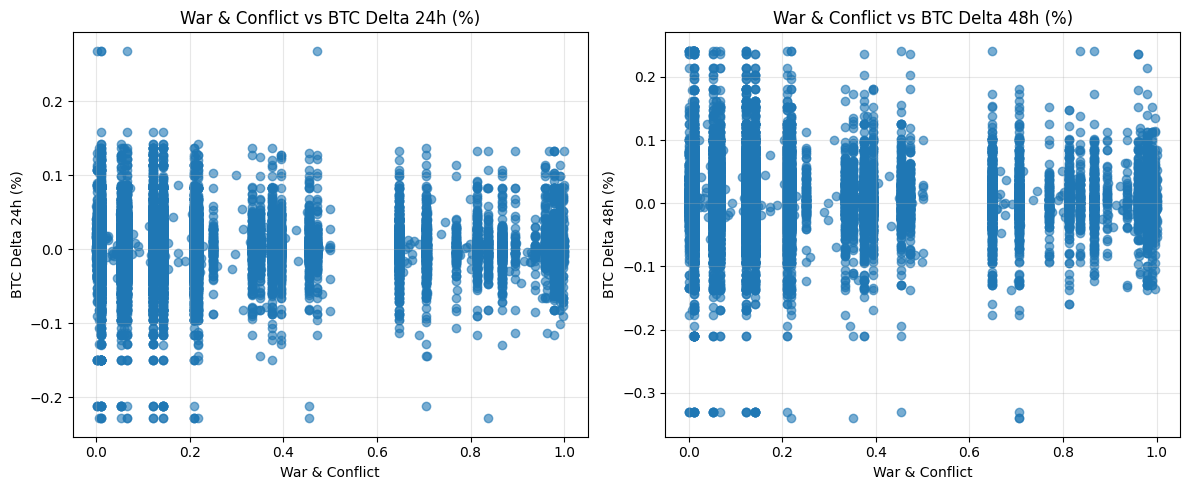

In [50]:
# Scatter plot: war_&_conflict vs BTC deltas
plot_google_vs_btc_deltas('war_&_conflict', 'War & Conflict')


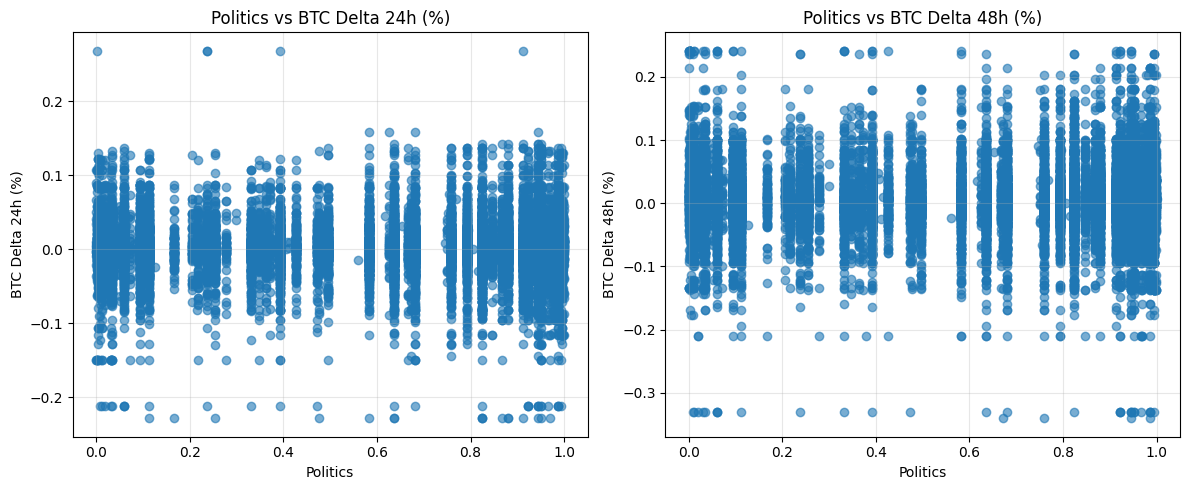

In [51]:
# Scatter plot: politics vs BTC deltas
plot_google_vs_btc_deltas('politics')


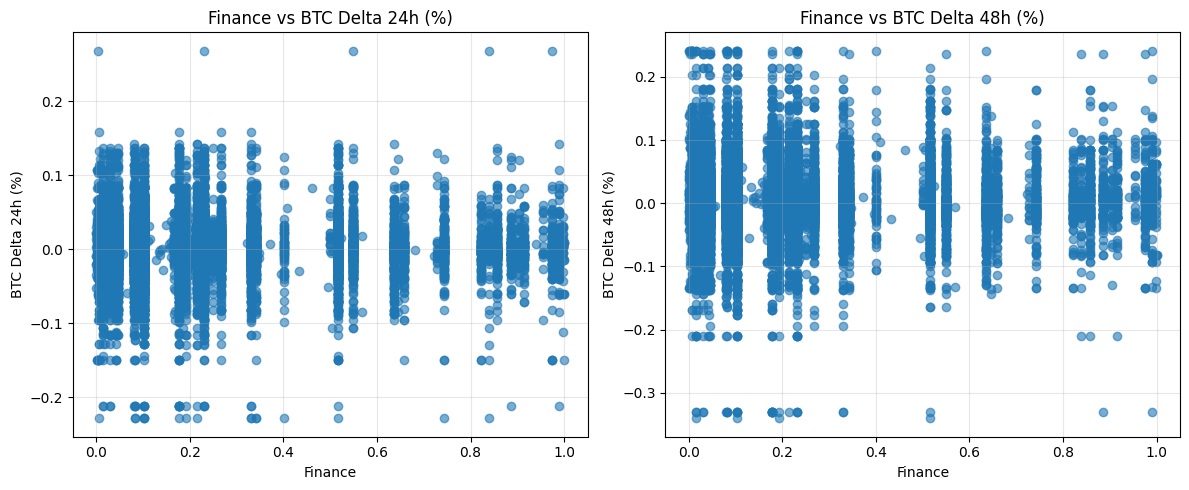

In [52]:
# Scatter plot: finance vs BTC deltas
plot_google_vs_btc_deltas('finance')


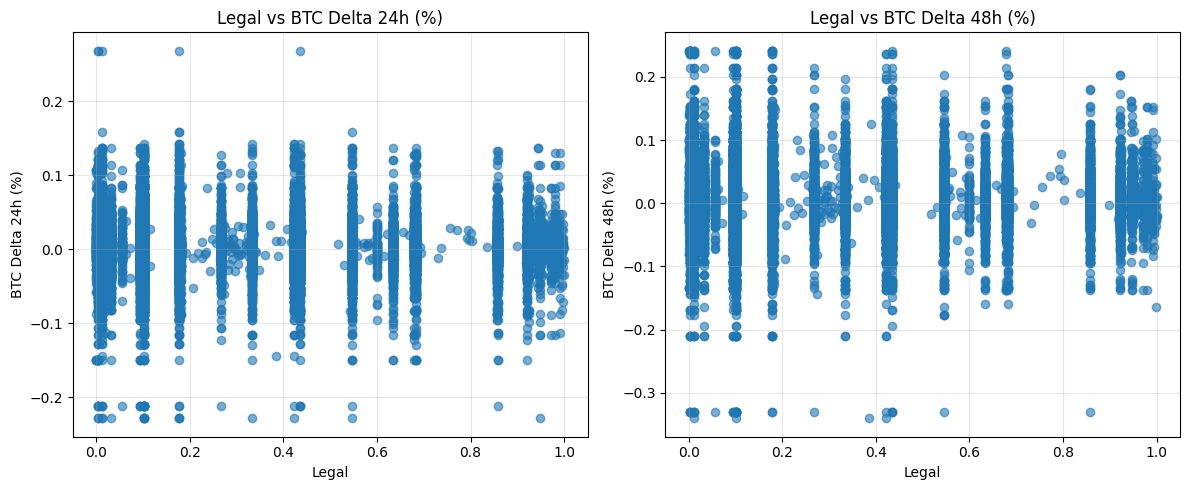

In [53]:
# Scatter plot: legal vs BTC deltas
plot_google_vs_btc_deltas('legal')


## Análisis de Puntos de Inflexión en el Precio del Bitcoin

En esta sección vamos a identificar tweets que marquen puntos de inflexión en el precio del Bitcoin. 
Para esto analizaremos:
1. La tendencia del Bitcoin en los 4 días previos al tweet
2. La tendencia del Bitcoin en las 24 horas posteriores al tweet  
3. Identificar cambios de tendencia (de bajista a alcista o viceversa)


In [54]:
# Cargar datos históricos de Bitcoin
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Cargar datos históricos de Bitcoin (15 minutos)
btc_data = pd.read_csv('../data/btc_15m_data_2018_to_2025.csv')

# Convertir columna de tiempo a datetime
btc_data['Open time'] = pd.to_datetime(btc_data['Open time'])
btc_data['date'] = btc_data['Open time'].dt.date

# Crear datos diarios agregando por día (usando el precio de cierre del último período del día)
btc_daily = btc_data.groupby('date').agg({
    'Open': 'first',
    'High': 'max', 
    'Low': 'min',
    'Close': 'last',
    'Volume': 'sum'
}).reset_index()

# Convertir date a datetime para facilitar cálculos
btc_daily['date'] = pd.to_datetime(btc_daily['date'])

print(f"{len(btc_daily)} días")
print(f"{btc_daily['date'].min()} a {btc_daily['date'].max()}")
btc_daily.head()


2804 días
2018-01-01 00:00:00 a 2025-09-04 00:00:00


,date,Open,High,Low,Close,Volume
0,2018-01-01,13715.65,13818.55,12750.00,13380.00,8609.915844
1,2018-01-02,13382.16,15473.49,12890.02,14675.11,20078.092111
2,2018-01-03,14690.00,15307.56,14150.00,14919.51,15905.667639
3,2018-01-04,14919.51,15280.00,13918.04,15059.54,21329.649574
4,2018-01-05,15059.56,17176.24,14600.00,16960.39,23251.491125


In [55]:
# Preparar datos de tweets
# Convertir fecha de tweets a datetime
df['date'] = pd.to_datetime(df['date'])
df['tweet_date'] = df['date'].dt.date

print(f"{len(df)} tweets")
print(f"{df['date'].min()} a {df['date'].max()}")

# Verificar que tenemos datos de Bitcoin para el rango de tweets
tweet_start = df['date'].min().date()
tweet_end = df['date'].max().date()
btc_start = btc_daily['date'].min().date()
btc_end = btc_daily['date'].max().date()

print(f"Tweets: {tweet_start} a {tweet_end}")
print(f"Bitcoin: {btc_start} a {btc_end}")

# Verificar superposición
overlap_start = max(tweet_start, btc_start)
overlap_end = min(tweet_end, btc_end)
print(f"Superposición: {overlap_start} a {overlap_end}")


22451 tweets
2018-01-02 12:09:00 a 2021-01-08 15:44:00
Tweets: 2018-01-02 a 2021-01-08
Bitcoin: 2018-01-01 a 2025-09-04
Superposición: 2018-01-02 a 2021-01-08


In [56]:
def calculate_trend(prices, days=4):
    """
    Calcula la tendencia de una serie de precios usando regresión lineal simple
    
    Args:
        prices: Lista de precios
        days: Número de días para el cálculo
    
    Returns:
        slope: Pendiente de la regresión (positiva = alcista, negativa = bajista)
        trend: 'alcista', 'bajista' o 'neutral'
    """
    if len(prices) < 2:
        return 0, 'neutral'
    
    # Crear índices para regresión lineal
    x = np.arange(len(prices))
    
    # Calcular pendiente usando mínimos cuadrados
    n = len(prices)
    sum_x = np.sum(x)
    sum_y = np.sum(prices)
    sum_xy = np.sum(x * prices)
    sum_x2 = np.sum(x * x)
    
    slope = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x * sum_x)
    
    # Clasificar tendencia
    # Usar un umbral mínimo para evitar ruido
    threshold = np.std(prices) * 0.1  # 10% de la desviación estándar
    
    if slope > threshold:
        trend = 'alcista'
    elif slope < -threshold:
        trend = 'bajista'
    else:
        trend = 'neutral'
    
    return slope, trend

# Función para obtener precios de Bitcoin en un rango de fechas
def get_btc_prices_for_period(start_date, end_date):
    """
    Obtiene los precios de cierre de Bitcoin para un período específico
    """
    mask = (btc_daily['date'].dt.date >= start_date) & (btc_daily['date'].dt.date <= end_date)
    period_data = btc_daily[mask].copy()
    return period_data['Close'].values

# Test de la función
test_prices = [100, 102, 105, 103, 108]
slope, trend = calculate_trend(test_prices)
print(f"Slope: {slope:.4f}, Trend: {trend}")


Slope: 1.7000, Trend: alcista


In [57]:
# Calcular tendencias para cada tweet
def analyze_tweet_impact(tweet_row):
    """
    Analiza el impacto de un tweet en el precio del Bitcoin
    """
    tweet_date = tweet_row['tweet_date']
    
    # Calcular fechas de análisis
    start_before = tweet_date - timedelta(days=4)
    end_before = tweet_date - timedelta(days=1)
    start_after = tweet_date
    end_after = tweet_date + timedelta(days=1)
    
    # Obtener precios antes del tweet (4 días previos)
    prices_before = get_btc_prices_for_period(start_before, end_before)
    
    # Obtener precios después del tweet (24 horas)
    prices_after = get_btc_prices_for_period(start_after, end_after)
    
    # Calcular tendencias
    if len(prices_before) >= 2:
        slope_before, trend_before = calculate_trend(prices_before)
    else:
        slope_before, trend_before = 0, 'neutral'
    
    if len(prices_after) >= 2:
        slope_after, trend_after = calculate_trend(prices_after)
    else:
        slope_after, trend_after = 0, 'neutral'
    
    # Determinar si hay cambio de tendencia
    inflection = False
    if trend_before != 'neutral' and trend_after != 'neutral' and trend_before != trend_after:
        inflection = True
    
    return {
        'slope_before': slope_before,
        'trend_before': trend_before,
        'slope_after': slope_after, 
        'trend_after': trend_after,
        'inflection': inflection,
        'prices_before_count': len(prices_before),
        'prices_after_count': len(prices_after)
    }

# Aplicar análisis a una muestra de tweets primero (para probar)
sample_df = df.head(100).copy()

# Aplicar análisis
results = []
for idx, row in sample_df.iterrows():
    result = analyze_tweet_impact(row)
    result['tweet_idx'] = idx
    results.append(result)

# Convertir a DataFrame
results_df = pd.DataFrame(results)
print(f"{len(results_df)} tweets analizados")
print(f"Datos suficientes antes: {(results_df['prices_before_count'] >= 2).sum()}")
print(f"Datos suficientes después: {(results_df['prices_after_count'] >= 2).sum()}")
print(f"Puntos de inflexión: {results_df['inflection'].sum()}")

results_df.head()


100 tweets analizados
Datos suficientes antes: 100
Datos suficientes después: 100
Puntos de inflexión: 47


,slope_before,trend_before,slope_after,trend_after,inflection,prices_before_count,prices_after_count,tweet_idx
0,67.526,alcista,-9.20,bajista,True,4,2,0
1,184.041,alcista,2.68,alcista,False,4,2,1
2,90.139,alcista,-108.09,bajista,True,4,2,2
3,184.041,alcista,2.68,alcista,False,4,2,3
4,184.041,alcista,2.68,alcista,False,4,2,4


In [58]:
# Aplicar el análisis a TODOS los tweets

# Filtrar tweets que tienen datos de Bitcoin disponibles
df['date'] = pd.to_datetime(df['date'])
df['tweet_date'] = df['date'].dt.date

# Filtrar tweets dentro del rango de datos de Bitcoin
btc_start = btc_daily['date'].min().date()
btc_end = btc_daily['date'].max().date()

# Necesitamos al menos 4 días antes y 1 día después
analysis_start = btc_start + timedelta(days=4)
analysis_end = btc_end - timedelta(days=1)

valid_tweets = df[(df['tweet_date'] >= analysis_start) & (df['tweet_date'] <= analysis_end)].copy()
print(f"{len(valid_tweets)} de {len(df)} tweets válidos")

# Aplicar análisis a todos los tweets válidos
all_results = []
for idx, row in valid_tweets.iterrows():
    result = analyze_tweet_impact(row)
    result['tweet_idx'] = idx
    result['tweet_date'] = row['tweet_date']
    result['tweet_text'] = row['text'][:100] + "..." if len(row['text']) > 100 else row['text']
    result['favorites'] = row['favorites']
    result['retweets'] = row['retweets']
    all_results.append(result)

# Convertir a DataFrame
all_results_df = pd.DataFrame(all_results)

print(f"{len(all_results_df)} tweets analizados")
print(f"Datos suficientes: {((all_results_df['prices_before_count'] >= 2) & (all_results_df['prices_after_count'] >= 2)).sum()}")
print(f"Puntos de inflexión: {all_results_df['inflection'].sum()}")

print(f"\nTendencias ANTES:")
print(all_results_df['trend_before'].value_counts())

print(f"\nTendencias DESPUÉS:")
print(all_results_df['trend_after'].value_counts())

all_results_df.head()


22424 de 22451 tweets válidos
22424 tweets analizados
Datos suficientes: 22424
Puntos de inflexión: 10960

Tendencias ANTES:
trend_before
alcista    11563
bajista     9116
neutral     1745
Name: count, dtype: int64

Tendencias DESPUÉS:
trend_after
alcista    12237
bajista    10187
Name: count, dtype: int64


,slope_before,trend_before,slope_after,trend_after,inflection,prices_before_count,prices_after_count,tweet_idx,tweet_date,tweet_text,favorites,retweets
0,67.526,alcista,-9.20,bajista,True,4,2,0,2020-03-03,I was thrilled to be back in the Great city of...,73748,17404
1,184.041,alcista,2.68,alcista,False,4,2,1,2020-01-17,RT @CBS_Herridge: READ: Letter to surveillance...,0,7396
2,90.139,alcista,-108.09,bajista,True,4,2,2,2020-09-12,The Unsolicited Mail In Ballot Scam is a major...,80527,23502
3,184.041,alcista,2.68,alcista,False,4,2,3,2020-01-17,RT @MZHemingway: Very friendly telling of even...,0,9081
4,184.041,alcista,2.68,alcista,False,4,2,4,2020-01-17,RT @WhiteHouse: President @realDonaldTrump ann...,0,25048


In [59]:
# ANÁLISIS CORREGIDO: Solo período de tweets de Trump (2018-2021)

# Redefinir el período de análisis solo para cuando tenemos tweets
trump_tweet_start = df['date'].min().date()  # 2018-01-02
trump_tweet_end = df['date'].max().date()    # 2021-01-08

print(f"{trump_tweet_start} a {trump_tweet_end}")

# Filtrar datos de Bitcoin solo para este período
btc_trump_period = btc_daily[
    (btc_daily['date'].dt.date >= trump_tweet_start) & 
    (btc_daily['date'].dt.date <= trump_tweet_end)
].copy()

print(f"{len(btc_trump_period)} días")
print(f"${btc_trump_period['Close'].min():,.2f} - ${btc_trump_period['Close'].max():,.2f}")

# Re-analizar solo los tweets en este período
trump_results = []
for idx, row in df.iterrows():
    tweet_date = row['date'].date()
    
    # Solo analizar si está en el período de datos de Bitcoin disponibles
    if (tweet_date >= btc_trump_period['date'].dt.date.min() and 
        tweet_date <= btc_trump_period['date'].dt.date.max()):
        
        # Calcular fechas de análisis
        start_before = tweet_date - timedelta(days=4)
        end_before = tweet_date - timedelta(days=1)
        start_after = tweet_date
        end_after = tweet_date + timedelta(days=1)
        
        # Obtener precios del período Trump
        prices_before = btc_trump_period[
            (btc_trump_period['date'].dt.date >= start_before) & 
            (btc_trump_period['date'].dt.date <= end_before)
        ]['Close'].values
        
        prices_after = btc_trump_period[
            (btc_trump_period['date'].dt.date >= start_after) & 
            (btc_trump_period['date'].dt.date <= end_after)
        ]['Close'].values
        
        # Calcular tendencias
        if len(prices_before) >= 2:
            slope_before, trend_before = calculate_trend(prices_before)
        else:
            slope_before, trend_before = 0, 'neutral'
        
        if len(prices_after) >= 2:
            slope_after, trend_after = calculate_trend(prices_after)
        else:
            slope_after, trend_after = 0, 'neutral'
        
        # Determinar si hay cambio de tendencia
        inflection = False
        if trend_before != 'neutral' and trend_after != 'neutral' and trend_before != trend_after:
            inflection = True
        
        trump_results.append({
            'tweet_idx': idx,
            'tweet_date': tweet_date,
            'tweet_text': row['text'][:100] + "..." if len(row['text']) > 100 else row['text'],
            'favorites': row['favorites'],
            'retweets': row['retweets'],
            'engagement': row['favorites'] + row['retweets'],
            'slope_before': slope_before,
            'trend_before': trend_before,
            'slope_after': slope_after,
            'trend_after': trend_after,
            'inflection': inflection,
            'prices_before_count': len(prices_before),
            'prices_after_count': len(prices_after)
        })

trump_results_df = pd.DataFrame(trump_results)

print(f"{len(trump_results_df)} tweets analizados")
print(f"Datos suficientes: {((trump_results_df['prices_before_count'] >= 2) & (trump_results_df['prices_after_count'] >= 2)).sum()}")
print(f"Puntos de inflexión: {trump_results_df['inflection'].sum()}")

trump_results_df.head()


2018-01-02 a 2021-01-08
1103 días
$3,211.72 - $40,582.81
22451 tweets analizados
Datos suficientes: 22432
Puntos de inflexión: 10958


,tweet_idx,tweet_date,tweet_text,favorites,retweets,engagement,slope_before,trend_before,slope_after,trend_after,inflection,prices_before_count,prices_after_count
0,0,2020-03-03,I was thrilled to be back in the Great city of...,73748,17404,91152,67.526,alcista,-9.20,bajista,True,4,2
1,1,2020-01-17,RT @CBS_Herridge: READ: Letter to surveillance...,0,7396,7396,184.041,alcista,2.68,alcista,False,4,2
2,2,2020-09-12,The Unsolicited Mail In Ballot Scam is a major...,80527,23502,104029,90.139,alcista,-108.09,bajista,True,4,2
3,3,2020-01-17,RT @MZHemingway: Very friendly telling of even...,0,9081,9081,184.041,alcista,2.68,alcista,False,4,2
4,4,2020-01-17,RT @WhiteHouse: President @realDonaldTrump ann...,0,25048,25048,184.041,alcista,2.68,alcista,False,4,2


In [60]:
# Análisis de puntos de inflexión en el período Trump
trump_inflection_tweets = trump_results_df[trump_results_df['inflection'] == True].copy()

if len(trump_inflection_tweets) > 0:
    print(f"{len(trump_inflection_tweets)} puntos de inflexión")
    
    # Ordenar por engagement
    trump_inflection_tweets = trump_inflection_tweets.sort_values('engagement', ascending=False)
    
    print(f"\nTop 10 tweets:")
    for i, (_, tweet) in enumerate(trump_inflection_tweets.head(10).iterrows()):
        print(f"\n{i+1}. {tweet['tweet_date']}")
        print(f"   {tweet['trend_before']} → {tweet['trend_after']}")
        print(f"   {tweet['engagement']:,} (♥{tweet['favorites']:,} + ↻{tweet['retweets']:,})")
        print(f"   {tweet['tweet_text']}")
        
    # Mostrar estadísticas de cambios de tendencia
    print(f"\nCambios de tendencia:")
    trend_changes = trump_inflection_tweets.groupby(['trend_before', 'trend_after']).size()
    for (before, after), count in trend_changes.items():
        print(f"  {before} → {after}: {count}")
        
print(f"\nTendencias ANTES:")
print(trump_results_df['trend_before'].value_counts())

print(f"\nTendencias DESPUÉS:")
print(trump_results_df['trend_after'].value_counts())


10958 puntos de inflexión

Top 10 tweets:

1. 2020-10-03
   bajista → alcista
   1,359,475 (♥1,219,870 + ↻139,605)
   Going welI, I think! Thank you to all. LOVE!!!

2. 2020-11-05
   alcista → bajista
   869,267 (♥748,645 + ↻120,622)
   STOP THE COUNT!

3. 2020-01-08
   alcista → bajista
   855,846 (♥713,124 + ↻142,722)
   All is well! Missiles launched from Iran at two military bases located in Iraq. Assessment of casual...

4. 2020-11-16
   bajista → alcista
   829,983 (♥718,605 + ↻111,378)
   I WON THE ELECTION!

5. 2020-11-08
   alcista → bajista
   810,791 (♥689,597 + ↻121,194)
   Since when does the Lamestream Media call who our next president will be? We have all learned a lot ...

6. 2020-11-06
   alcista → bajista
   793,741 (♥677,422 + ↻116,319)
   Joe Biden should not wrongfully claim the office of the President. I could make that claim also. Leg...

7. 2019-12-25
   alcista → bajista
   787,848 (♥686,218 + ↻101,630)
   MERRY CHRISTMAS!

8. 2020-01-26
   bajista → alcista
  

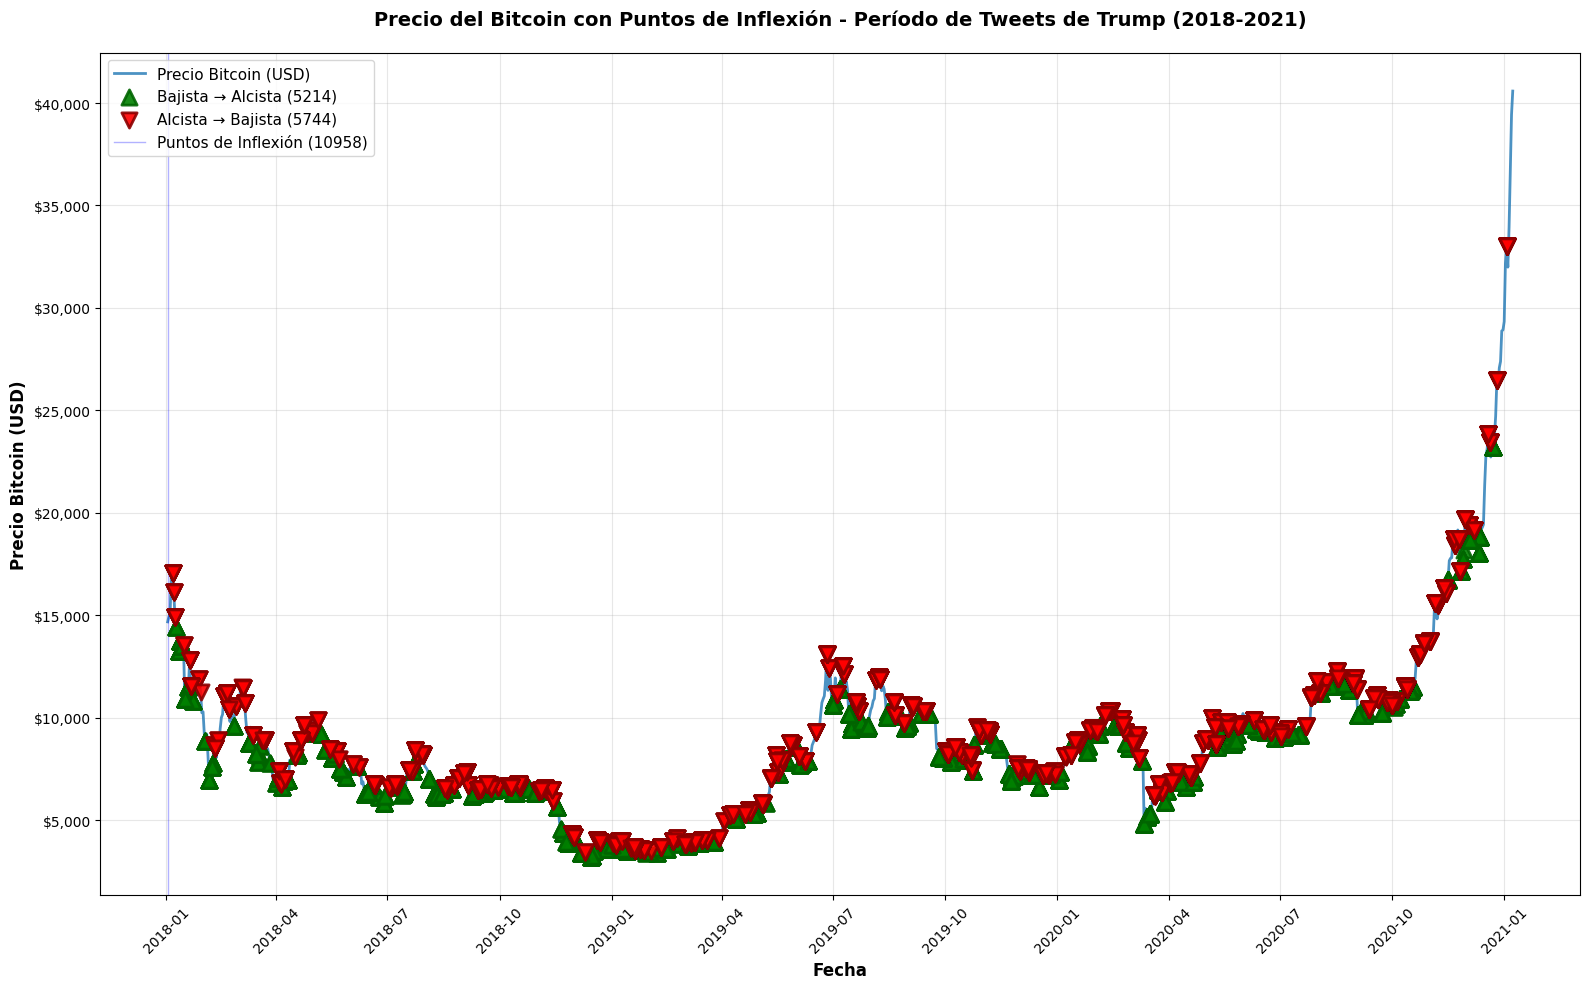

2018-01-02 a 2021-01-08
Puntos de inflexión: 10958
Bajista → alcista: 5214
Alcista → bajista: 5744
Engagement promedio: 68,980
Precio inicial: $14,675.11
Precio final: $40,582.81
Cambio total: +176.5%


In [61]:
# GRÁFICO CORREGIDO: Solo período de tweets de Trump (2018-2021)
def create_trump_period_chart():
    """
    Crea un gráfico del precio del Bitcoin marcando los puntos de inflexión
    SOLO para el período donde tenemos tweets de Trump (2018-2021)
    """
    # Crear figura más grande para mejor visualización
    fig, ax = plt.subplots(figsize=(16, 10))
    
    # Gráfico principal del precio de Bitcoin (solo período Trump)
    ax.plot(btc_trump_period['date'], btc_trump_period['Close'], 
            color='#1f77b4', linewidth=2, alpha=0.8, label='Precio Bitcoin (USD)')
    
    # Marcar puntos de inflexión si los hay
    if len(trump_inflection_tweets) > 0:
        # Separar por tipo de cambio de tendencia
        bajista_a_alcista = trump_inflection_tweets[
            (trump_inflection_tweets['trend_before'] == 'bajista') & 
            (trump_inflection_tweets['trend_after'] == 'alcista')
        ]
        
        alcista_a_bajista = trump_inflection_tweets[
            (trump_inflection_tweets['trend_before'] == 'alcista') & 
            (trump_inflection_tweets['trend_after'] == 'bajista')
        ]
        
        # Marcar puntos bajista → alcista (verde)
        if len(bajista_a_alcista) > 0:
            ba_dates = pd.to_datetime(bajista_a_alcista['tweet_date'])
            ba_prices = []
            for date in ba_dates:
                price_data = btc_trump_period[btc_trump_period['date'].dt.date == date.date()]
                if len(price_data) > 0:
                    ba_prices.append(price_data['Close'].iloc[0])
            
            if ba_prices:  # Solo si tenemos precios
                ax.scatter(ba_dates, ba_prices, 
                          color='green', s=120, alpha=0.9, 
                          marker='^', label=f'Bajista → Alcista ({len(bajista_a_alcista)})', 
                          zorder=5, edgecolors='darkgreen', linewidth=2)
        
        # Marcar puntos alcista → bajista (rojo)
        if len(alcista_a_bajista) > 0:
            ab_dates = pd.to_datetime(alcista_a_bajista['tweet_date'])
            ab_prices = []
            for date in ab_dates:
                price_data = btc_trump_period[btc_trump_period['date'].dt.date == date.date()]
                if len(price_data) > 0:
                    ab_prices.append(price_data['Close'].iloc[0])
            
            if ab_prices:  # Solo si tenemos precios
                ax.scatter(ab_dates, ab_prices, 
                          color='red', s=120, alpha=0.9, 
                          marker='v', label=f'Alcista → Bajista ({len(alcista_a_bajista)})', 
                          zorder=5, edgecolors='darkred', linewidth=2)
    
    # Configurar ejes y formato
    ax.set_xlabel('Fecha', fontsize=12, fontweight='bold')
    ax.set_ylabel('Precio Bitcoin (USD)', fontsize=12, fontweight='bold')
    ax.set_title('Precio del Bitcoin con Puntos de Inflexión - Período de Tweets de Trump (2018-2021)', 
                fontsize=14, fontweight='bold', pad=20)
    
    # Formato de fechas en el eje X (más apropiado para 3 años)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))  # Cada 3 meses
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    
    # Agregar línea azul a la leyenda
    if len(trump_inflection_tweets) > 0:
        ax.axvline(x=btc_trump_period['date'].iloc[0], color='blue', alpha=0.3, 
                  linewidth=1, linestyle='-', label=f'Puntos de Inflexión ({len(trump_inflection_tweets)})')
    
    # Grid y leyenda
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left', fontsize=11)
    
    # Formato del precio en el eje Y
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
    
    # Ajustar layout
    plt.tight_layout()
    
    return fig, ax

# Crear el gráfico corregido
fig, ax = create_trump_period_chart()
plt.show()

print(f"{trump_tweet_start} a {trump_tweet_end}")
print(f"Puntos de inflexión: {len(trump_inflection_tweets) if len(trump_inflection_tweets) > 0 else 0}")

if len(trump_inflection_tweets) > 0:
    bajista_alcista = len(trump_inflection_tweets[
        (trump_inflection_tweets['trend_before'] == 'bajista') & 
        (trump_inflection_tweets['trend_after'] == 'alcista')
    ])
    alcista_bajista = len(trump_inflection_tweets[
        (trump_inflection_tweets['trend_before'] == 'alcista') & 
        (trump_inflection_tweets['trend_after'] == 'bajista')
    ])
    
    print(f"Bajista → alcista: {bajista_alcista}")
    print(f"Alcista → bajista: {alcista_bajista}")
    print(f"Engagement promedio: {trump_inflection_tweets['engagement'].mean():,.0f}")
    
    # Precio de Bitcoin al inicio y final del período Trump
    btc_start_price = btc_trump_period['Close'].iloc[0]
    btc_end_price = btc_trump_period['Close'].iloc[-1]
    price_change = ((btc_end_price - btc_start_price) / btc_start_price) * 100
    
    print(f"Precio inicial: ${btc_start_price:,.2f}")
    print(f"Precio final: ${btc_end_price:,.2f}")
    print(f"Cambio total: {price_change:+.1f}%")


In [62]:
# Tabla completa de tweets que causaron inflexión
inflection_table = trump_inflection_tweets[['tweet_date', 'trend_before', 'trend_after', 'favorites', 'retweets', 'engagement', 'tweet_text']].copy()

# Ordenar por engagement descendente
inflection_table = inflection_table.sort_values('engagement', ascending=False)

# Resetear índice para numeración consecutiva
inflection_table = inflection_table.reset_index(drop=True)

# Mostrar estadísticas de la tabla
print(f"Total tweets con inflexión: {len(inflection_table)}")
print(f"Rango de fechas: {inflection_table['tweet_date'].min()} a {inflection_table['tweet_date'].max()}")
print(f"Engagement total: {inflection_table['engagement'].sum():,}")

inflection_table.head(20)


Total tweets con inflexión: 10958
Rango de fechas: 2018-01-06 a 2021-01-03
Engagement total: 755,883,471


,tweet_date,trend_before,trend_after,favorites,retweets,engagement,tweet_text
0,2020-10-03,bajista,alcista,1219870,139605,1359475,"Going welI, I think! Thank you to all. LOVE!!!"
1,2020-11-05,alcista,bajista,748645,120622,869267,STOP THE COUNT!
2,2020-01-08,alcista,bajista,713124,142722,855846,All is well! Missiles launched from Iran at tw...
3,2020-11-16,bajista,alcista,718605,111378,829983,I WON THE ELECTION!
4,2020-11-08,alcista,bajista,689597,121194,810791,Since when does the Lamestream Media call who ...
5,2020-11-06,alcista,bajista,677422,116319,793741,Joe Biden should not wrongfully claim the offi...
6,2019-12-25,alcista,bajista,686218,101630,787848,MERRY CHRISTMAS!
7,2020-01-26,bajista,alcista,695184,85722,780906,"Kobe Bryant, despite being one of the truly gr..."
8,2020-11-16,bajista,alcista,681676,97246,778922,I won the Election!
9,2020-11-06,alcista,bajista,652476,119892,772368,Where are the missing military ballots in Geor...


In [63]:
# Mostrar tabla completa con formato mejorado
import pandas as pd

# Crear una versión más legible de la tabla
display_table = inflection_table.copy()

# Truncar texto de tweets para mejor visualización
display_table['tweet_preview'] = display_table['tweet_text'].str[:80] + '...'

# Seleccionar columnas para mostrar
final_table = display_table[['tweet_date', 'trend_before', 'trend_after', 'favorites', 'retweets', 'engagement', 'tweet_preview']].copy()

# Renombrar columnas para mejor presentación
final_table.columns = ['Fecha', 'Tendencia Antes', 'Tendencia Después', 'Favoritos', 'Retweets', 'Engagement', 'Tweet (Preview)']

print(f"Tabla de {len(final_table)} tweets que causaron inflexión en Bitcoin:")
final_table


Tabla de 10958 tweets que causaron inflexión en Bitcoin:


,Fecha,Tendencia Antes,Tendencia Después,Favoritos,Retweets,Engagement,Tweet (Preview)
0,2020-10-03,bajista,alcista,1219870,139605,1359475,"Going welI, I think! Thank you to all. LOVE!!!..."
1,2020-11-05,alcista,bajista,748645,120622,869267,STOP THE COUNT!...
2,2020-01-08,alcista,bajista,713124,142722,855846,All is well! Missiles launched from Iran at tw...
3,2020-11-16,bajista,alcista,718605,111378,829983,I WON THE ELECTION!...
4,2020-11-08,alcista,bajista,689597,121194,810791,Since when does the Lamestream Media call who ...
...,...,...,...,...,...,...,...
10953,2020-07-11,bajista,alcista,0,0,0,Roger Stone was targeted by an illegal Witch H...
10954,2020-11-05,alcista,bajista,0,0,0,RT @EricTrump: 🚨🚨🚨 The amount of FRAUD being r...
10955,2020-11-06,alcista,bajista,0,0,0,I easily WIN the Presidency of the United Stat...
10956,2020-11-05,alcista,bajista,0,0,0,All of the recent Biden claimed States will be...


# Análisis de Combinación de Variables

Como observamos, una sola variable categórica no es suficiente para explicar las variaciones del Bitcoin. Vamos a implementar varias estrategias para combinar múltiples variables y encontrar patrones más complejos.


In [64]:
# 1. ESTRATEGIA 1: Scores Compuestos por Categoría

# Primero, vamos a crear scores compuestos que combinen variables relacionadas
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import seaborn as sns

# Definir grupos de variables relacionadas
variable_groups = {
    'toxicidad': ['toxic', 'insult', 'profanity', 'derogatory'],
    'violencia': ['death,_harm_&_tragedy', 'violent', 'firearms_&_weapons', 'public_safety'],
    'temas_sensibles': ['sexual', 'health', 'religion_&_belief', 'illicit_drugs'],
    'contexto_politico': ['politics', 'war_&_conflict', 'legal'],
    'finanzas': ['finance']
}

# Función para crear scores compuestos
def create_composite_scores(df, variable_groups):
    """
    Crea scores compuestos para cada grupo de variables
    """
    scores_df = df.copy()
    
    for group_name, variables in variable_groups.items():
        # Filtrar solo las variables que existen en el dataframe
        existing_vars = [var for var in variables if var in df.columns]
        
        if existing_vars:
            # Calcular score compuesto (suma ponderada)
            scores_df[f'{group_name}_score'] = df[existing_vars].sum(axis=1)
            
            # Calcular score normalizado (promedio)
            scores_df[f'{group_name}_normalized'] = df[existing_vars].mean(axis=1)
            
            # Calcular score máximo (intensidad máxima)
            scores_df[f'{group_name}_max'] = df[existing_vars].max(axis=1)
            
            print(f"Grupo '{group_name}': {len(existing_vars)} variables")
            print(f"  Variables: {existing_vars}")
    
    return scores_df

# Crear scores compuestos
df_with_scores = create_composite_scores(df, variable_groups)

# Mostrar las nuevas columnas creadas
score_columns = [col for col in df_with_scores.columns if col.endswith('_score') or col.endswith('_normalized') or col.endswith('_max')]
print(f"\nNuevas columnas creadas: {score_columns}")

# Mostrar estadísticas de los scores
print("\nEstadísticas de scores compuestos:")
df_with_scores[score_columns].describe()


Grupo 'toxicidad': 4 variables
  Variables: ['toxic', 'insult', 'profanity', 'derogatory']
Grupo 'violencia': 4 variables
  Variables: ['death,_harm_&_tragedy', 'violent', 'firearms_&_weapons', 'public_safety']
Grupo 'temas_sensibles': 4 variables
  Variables: ['sexual', 'health', 'religion_&_belief', 'illicit_drugs']
Grupo 'contexto_politico': 3 variables
  Variables: ['politics', 'war_&_conflict', 'legal']
Grupo 'finanzas': 1 variables
  Variables: ['finance']

Nuevas columnas creadas: ['toxicidad_score', 'toxicidad_normalized', 'toxicidad_max', 'violencia_score', 'violencia_normalized', 'violencia_max', 'temas_sensibles_score', 'temas_sensibles_normalized', 'temas_sensibles_max', 'contexto_politico_score', 'contexto_politico_normalized', 'contexto_politico_max', 'finanzas_score', 'finanzas_normalized', 'finanzas_max']

Estadísticas de scores compuestos:


,toxicidad_score,toxicidad_normalized,toxicidad_max,violencia_score,violencia_normalized,violencia_max,temas_sensibles_score,temas_sensibles_normalized,temas_sensibles_max,contexto_politico_score,contexto_politico_normalized,contexto_politico_max,finanzas_score,finanzas_normalized,finanzas_max
count,22451.000000,22451.000000,22451.000000,22451.000000,22451.000000,22451.000000,22451.000000,22451.000000,22451.000000,22451.000000,22451.000000,22451.000000,22451.000000,22451.000000,22451.000000
mean,0.212595,0.053149,0.090321,0.536050,0.134012,0.288451,0.379873,0.094968,0.237116,1.136367,0.378789,0.696460,0.198476,0.198476,0.198476
std,0.369245,0.092311,0.157003,0.579233,0.144808,0.288458,0.378658,0.094665,0.261150,0.631453,0.210484,0.333500,0.214808,0.214808,0.214808
min,0.003072,0.000768,0.003072,0.000000,0.000000,0.000000,0.005991,0.001498,0.003537,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.018357,0.004589,0.005484,0.108870,0.027217,0.073482,0.115137,0.028784,0.057377,0.689278,0.229759,0.435185,0.045953,0.045953,0.045953
50%,0.045489,0.011372,0.019228,0.307443,0.076861,0.189759,0.226125,0.056531,0.115128,1.173911,0.391304,0.867188,0.102379,0.102379,0.102379
75%,0.213605,0.053401,0.089092,0.806279,0.201570,0.428571,0.519905,0.129976,0.312376,1.587006,0.529002,0.950920,0.230942,0.230942,0.230942
max,2.946993,0.736748,1.000000,3.784632,0.946158,1.000000,3.051887,0.762972,1.000000,2.897036,0.965679,1.000000,1.000000,1.000000,1.000000


In [65]:
# 2. ESTRATEGIA 2: Score de Impacto Total

# Crear un score de impacto total que combine todas las variables
def create_total_impact_score(df):
    """
    Crea un score de impacto total combinando todas las variables categóricas
    """
    # Variables categóricas disponibles
    categorical_vars = [
        'toxic', 'insult', 'profanity', 'derogatory', 'sexual', 
        'death,_harm_&_tragedy', 'violent', 'firearms_&_weapons', 
        'public_safety', 'health', 'religion_&_belief', 'illicit_drugs', 
        'war_&_conflict', 'politics', 'finance', 'legal'
    ]
    
    # Filtrar solo las variables que existen
    existing_vars = [var for var in categorical_vars if var in df.columns]
    
    # Score simple: suma de todas las variables
    df['total_impact_score'] = df[existing_vars].sum(axis=1)
    
    # Score ponderado: dar más peso a ciertas variables
    weights = {
        'toxic': 1.5,
        'insult': 1.2,
        'profanity': 1.1,
        'derogatory': 1.3,
        'sexual': 1.0,
        'death,_harm_&_tragedy': 2.0,
        'violent': 1.8,
        'firearms_&_weapons': 1.7,
        'public_safety': 1.6,
        'health': 1.0,
        'religion_&_belief': 1.2,
        'illicit_drugs': 1.4,
        'war_&_conflict': 1.9,
        'politics': 1.5,
        'finance': 2.5,  # Mayor peso para finanzas
        'legal': 1.3
    }
    
    # Aplicar pesos
    weighted_score = 0
    for var in existing_vars:
        weight = weights.get(var, 1.0)
        weighted_score += df[var] * weight
    
    df['total_impact_weighted'] = weighted_score
    
    # Score de intensidad: máximo valor entre todas las variables
    df['max_intensity'] = df[existing_vars].max(axis=1)
    
    # Score de diversidad: número de variables activas (> 0)
    df['diversity_score'] = (df[existing_vars] > 0).sum(axis=1)
    
    print(f"Variables utilizadas: {len(existing_vars)}")
    print(f"Variables: {existing_vars}")
    
    return df

# Aplicar función
df_with_scores = create_total_impact_score(df_with_scores)

# Mostrar estadísticas de los nuevos scores
new_score_cols = ['total_impact_score', 'total_impact_weighted', 'max_intensity', 'diversity_score']
print("\nEstadísticas de scores de impacto:")
df_with_scores[new_score_cols].describe()


Variables utilizadas: 16
Variables: ['toxic', 'insult', 'profanity', 'derogatory', 'sexual', 'death,_harm_&_tragedy', 'violent', 'firearms_&_weapons', 'public_safety', 'health', 'religion_&_belief', 'illicit_drugs', 'war_&_conflict', 'politics', 'finance', 'legal']

Estadísticas de scores de impacto:


,total_impact_score,total_impact_weighted,max_intensity,diversity_score
count,22451.000000,22451.000000,22451.000000,22451.000000
mean,2.463361,3.907899,0.782849,15.538016
std,1.407527,2.212061,0.269668,0.571728
min,0.032795,0.043288,0.006250,8.000000
25%,1.439378,2.299923,0.680934,15.000000
50%,2.241393,3.569506,0.921053,16.000000
75%,3.286583,5.212169,0.976744,16.000000
max,10.406850,15.336243,1.000000,16.000000


CORRELACIONES CON BTC DELTA 24H:
violencia_max            :  0.0310
violencia_score          :  0.0299
violencia_normalized     :  0.0299
total_impact_score       :  0.0255
total_impact_weighted    :  0.0252
temas_sensibles_normalized:  0.0204
temas_sensibles_score    :  0.0204
toxicidad_score          :  0.0197
toxicidad_normalized     :  0.0197
temas_sensibles_max      :  0.0194
toxicidad_max            :  0.0185
diversity_score          :  0.0139
contexto_politico_score  :  0.0075
contexto_politico_normalized:  0.0075
finanzas_score           : -0.0056
finanzas_max             : -0.0056
finanzas_normalized      : -0.0056
max_intensity            :  0.0036
contexto_politico_max    : -0.0033

CORRELACIONES CON BTC DELTA 48H:
temas_sensibles_max      :  0.0378
temas_sensibles_score    :  0.0338
temas_sensibles_normalized:  0.0338
violencia_normalized     :  0.0272
violencia_score          :  0.0272
violencia_max            :  0.0266
total_impact_score       :  0.0252
total_impact_weigh

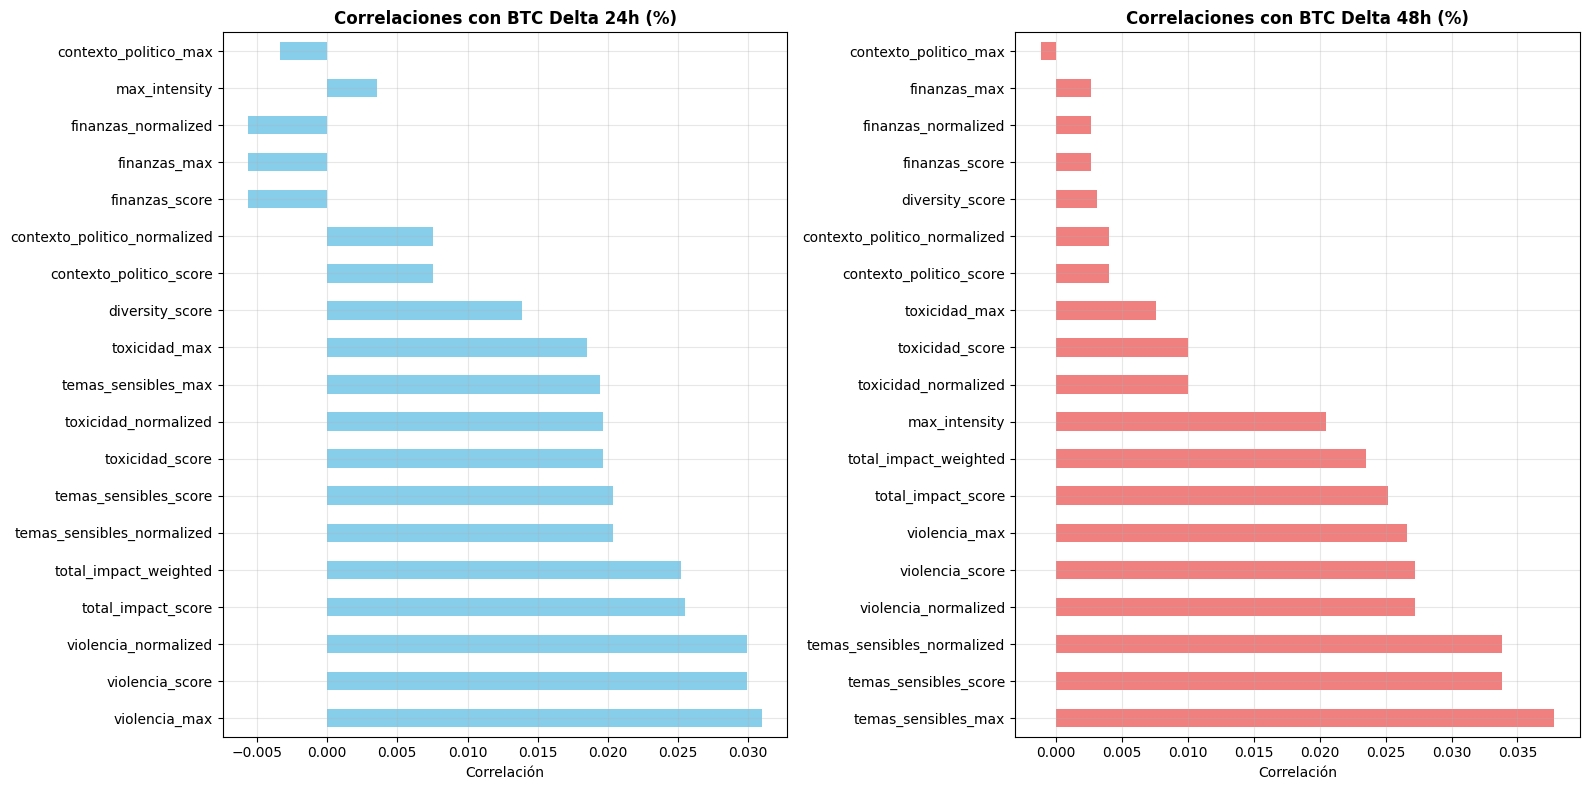

In [66]:
# 3. ESTRATEGIA 3: Análisis de Correlación con Variables Combinadas

# Analizar correlaciones entre los nuevos scores compuestos y las variaciones del Bitcoin
def analyze_correlations_with_combined_variables(df):
    """
    Analiza correlaciones entre variables combinadas y variaciones del Bitcoin
    """
    # Variables objetivo (variaciones del Bitcoin)
    target_vars = ['btc_delta_24h_pct', 'btc_delta_48h_pct']
    
    # Variables combinadas (scores compuestos)
    combined_vars = [
        'total_impact_score', 'total_impact_weighted', 'max_intensity', 'diversity_score',
        'toxicidad_score', 'toxicidad_normalized', 'toxicidad_max',
        'violencia_score', 'violencia_normalized', 'violencia_max',
        'temas_sensibles_score', 'temas_sensibles_normalized', 'temas_sensibles_max',
        'contexto_politico_score', 'contexto_politico_normalized', 'contexto_politico_max',
        'finanzas_score', 'finanzas_normalized', 'finanzas_max'
    ]
    
    # Filtrar solo las variables que existen
    existing_combined = [var for var in combined_vars if var in df.columns]
    
    # Calcular matriz de correlación
    correlation_data = df[target_vars + existing_combined].corr()
    
    # Extraer correlaciones con las variables objetivo
    correlations_24h = correlation_data['btc_delta_24h_pct'][existing_combined].sort_values(key=abs, ascending=False)
    correlations_48h = correlation_data['btc_delta_48h_pct'][existing_combined].sort_values(key=abs, ascending=False)
    
    print("CORRELACIONES CON BTC DELTA 24H:")
    print("="*50)
    for var, corr in correlations_24h.items():
        print(f"{var:25s}: {corr:7.4f}")
    
    print("\nCORRELACIONES CON BTC DELTA 48H:")
    print("="*50)
    for var, corr in correlations_48h.items():
        print(f"{var:25s}: {corr:7.4f}")
    
    # Crear gráfico de correlaciones
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    # Correlaciones con BTC 24h
    correlations_24h.plot(kind='barh', ax=ax1, color='skyblue')
    ax1.set_title('Correlaciones con BTC Delta 24h (%)', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Correlación')
    ax1.grid(True, alpha=0.3)
    
    # Correlaciones con BTC 48h
    correlations_48h.plot(kind='barh', ax=ax2, color='lightcoral')
    ax2.set_title('Correlaciones con BTC Delta 48h (%)', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Correlación')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return correlations_24h, correlations_48h

# Ejecutar análisis de correlaciones
corr_24h, corr_48h = analyze_correlations_with_combined_variables(df_with_scores)


Clusters 3: Inercia = 261993.23
Clusters 4: Inercia = 243285.87
Clusters 5: Inercia = 227628.95
Clusters 6: Inercia = 214061.16


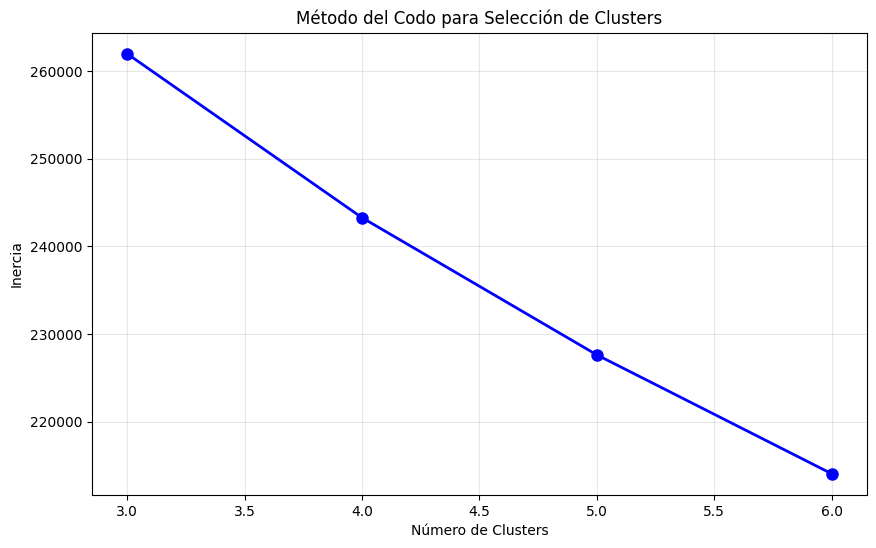


ANÁLISIS DE CLUSTERS (k=4):

CLUSTER 0 (n=5,099 tweets):
----------------------------------------
Variables más altas:
  politics            : 0.7751
  legal               : 0.5235
  public_safety       : 0.4846
  war_&_conflict      : 0.4321
  violent             : 0.2886
BTC Delta 24h: 0.0029 (+0.29%)
BTC Delta 48h: 0.0068 (+0.68%)

CLUSTER 1 (n=1,449 tweets):
----------------------------------------
Variables más altas:
  health              : 0.8621
  politics            : 0.4539
  finance             : 0.2472
  illicit_drugs       : 0.2123
  death,_harm_&_tragedy: 0.2083
BTC Delta 24h: 0.0028 (+0.28%)
BTC Delta 48h: 0.0129 (+1.29%)

CLUSTER 2 (n=13,794 tweets):
----------------------------------------
Variables más altas:
  politics            : 0.6060
  finance             : 0.1870
  legal               : 0.1782
  war_&_conflict      : 0.1470
  death,_harm_&_tragedy: 0.0950
BTC Delta 24h: 0.0013 (+0.13%)
BTC Delta 48h: 0.0045 (+0.45%)

CLUSTER 3 (n=2,109 tweets):
---------------

In [67]:
# 4. ESTRATEGIA 4: Clustering para Encontrar Patrones Complejos

# Aplicar clustering para encontrar patrones complejos en las combinaciones de variables
def perform_clustering_analysis(df):
    """
    Realiza análisis de clustering para encontrar patrones complejos
    """
    # Variables para clustering (todas las variables categóricas normalizadas)
    clustering_vars = [
        'toxic', 'insult', 'profanity', 'derogatory', 'sexual', 
        'death,_harm_&_tragedy', 'violent', 'firearms_&_weapons', 
        'public_safety', 'health', 'religion_&_belief', 'illicit_drugs', 
        'war_&_conflict', 'politics', 'finance', 'legal'
    ]
    
    # Filtrar solo las variables que existen
    existing_vars = [var for var in clustering_vars if var in df.columns]
    
    # Preparar datos para clustering
    X = df[existing_vars].values
    
    # Normalizar datos
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Aplicar K-means con diferentes números de clusters
    n_clusters_options = [3, 4, 5, 6]
    clustering_results = {}
    
    for n_clusters in n_clusters_options:
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        clusters = kmeans.fit_predict(X_scaled)
        
        clustering_results[n_clusters] = {
            'model': kmeans,
            'clusters': clusters,
            'inertia': kmeans.inertia_
        }
        
        print(f"Clusters {n_clusters}: Inercia = {kmeans.inertia_:.2f}")
    
    # Seleccionar el mejor número de clusters (método del codo)
    inertias = [result['inertia'] for result in clustering_results.values()]
    
    plt.figure(figsize=(10, 6))
    plt.plot(n_clusters_options, inertias, 'bo-', linewidth=2, markersize=8)
    plt.xlabel('Número de Clusters')
    plt.ylabel('Inercia')
    plt.title('Método del Codo para Selección de Clusters')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Usar 4 clusters como resultado (punto de inflexión típico)
    best_n_clusters = 4
    best_model = clustering_results[best_n_clusters]['model']
    best_clusters = clustering_results[best_n_clusters]['clusters']
    
    # Agregar clusters al dataframe
    df['cluster'] = best_clusters
    
    # Analizar características de cada cluster
    print(f"\nANÁLISIS DE CLUSTERS (k={best_n_clusters}):")
    print("="*60)
    
    cluster_analysis = df.groupby('cluster')[existing_vars + ['btc_delta_24h_pct', 'btc_delta_48h_pct']].mean()
    
    for cluster_id in range(best_n_clusters):
        cluster_data = cluster_analysis.loc[cluster_id]
        cluster_size = (df['cluster'] == cluster_id).sum()
        
        print(f"\nCLUSTER {cluster_id} (n={cluster_size:,} tweets):")
        print("-" * 40)
        
        # Variables más altas en este cluster
        top_vars = cluster_data[existing_vars].sort_values(ascending=False).head(5)
        print("Variables más altas:")
        for var, value in top_vars.items():
            print(f"  {var:20s}: {value:.4f}")
        
        # Impacto en Bitcoin
        btc_24h = cluster_data['btc_delta_24h_pct']
        btc_48h = cluster_data['btc_delta_48h_pct']
        print(f"BTC Delta 24h: {btc_24h:.4f} ({btc_24h*100:+.2f}%)")
        print(f"BTC Delta 48h: {btc_48h:.4f} ({btc_48h*100:+.2f}%)")
    
    return df, best_model, clustering_results

# Ejecutar análisis de clustering
df_with_clusters, best_model, clustering_results = perform_clustering_analysis(df_with_scores)


In [68]:
# 5. ESTRATEGIA 5: Análisis de Interacciones entre Variables

# Crear features de interacción entre variables para capturar patrones más complejos
def create_interaction_features(df):
    """
    Crea features de interacción entre variables para capturar patrones complejos
    """
    # Variables base para interacciones
    base_vars = ['toxic', 'insult', 'profanity', 'derogatory', 'politics', 'finance', 'violent']
    
    # Filtrar solo las variables que existen
    existing_base_vars = [var for var in base_vars if var in df.columns]
    
    print(f"Variables base para interacciones: {existing_base_vars}")
    
    # Crear interacciones multiplicativas
    interaction_features = {}
    
    for i, var1 in enumerate(existing_base_vars):
        for j, var2 in enumerate(existing_base_vars):
            if i < j:  # Evitar duplicados
                interaction_name = f"{var1}_x_{var2}"
                interaction_features[interaction_name] = df[var1] * df[var2]
    
    # Crear interacciones aditivas (combinaciones)
    additive_features = {}
    
    # Combinaciones de toxicidad
    toxic_vars = [var for var in existing_base_vars if var in ['toxic', 'insult', 'profanity', 'derogatory']]
    if len(toxic_vars) > 1:
        additive_features['toxicidad_combinada'] = df[toxic_vars].sum(axis=1)
    
    # Combinaciones de impacto político
    political_vars = [var for var in existing_base_vars if var in ['politics', 'violent', 'finance']]
    if len(political_vars) > 1:
        additive_features['impacto_politico'] = df[political_vars].sum(axis=1)
    
    # Crear interacciones condicionales
    conditional_features = {}
    
    # Interacción condicional: alta toxicidad + alta política
    if 'toxic' in existing_base_vars and 'politics' in existing_base_vars:
        conditional_features['toxic_political'] = (df['toxic'] > df['toxic'].quantile(0.8)) & (df['politics'] > df['politics'].quantile(0.8))
    
    # Interacción condicional: alta violencia + alta finanzas
    if 'violent' in existing_base_vars and 'finance' in existing_base_vars:
        conditional_features['violent_financial'] = (df['violent'] > df['violent'].quantile(0.8)) & (df['finance'] > df['finance'].quantile(0.8))
    
    # Agregar todas las interacciones al dataframe
    for name, values in interaction_features.items():
        df[name] = values
    
    for name, values in additive_features.items():
        df[name] = values
    
    for name, values in conditional_features.items():
        df[name] = values.astype(int)
    
    # Mostrar estadísticas de las nuevas features
    all_new_features = list(interaction_features.keys()) + list(additive_features.keys()) + list(conditional_features.keys())
    
    print(f"\nNuevas features de interacción creadas: {len(all_new_features)}")
    print("Features:")
    for feature in all_new_features:
        print(f"  - {feature}")
    
    # Analizar correlaciones de las nuevas features con BTC
    if all_new_features:
        correlations = df[all_new_features + ['btc_delta_24h_pct', 'btc_delta_48h_pct']].corr()
        
        print("\nCORRELACIONES DE FEATURES DE INTERACCIÓN:")
        print("="*60)
        
        corr_24h = correlations['btc_delta_24h_pct'][all_new_features].sort_values(key=abs, ascending=False)
        corr_48h = correlations['btc_delta_48h_pct'][all_new_features].sort_values(key=abs, ascending=False)
        
        print("Con BTC Delta 24h:")
        for feature, corr in corr_24h.head(10).items():
            print(f"  {feature:30s}: {corr:7.4f}")
        
        print("\nCon BTC Delta 48h:")
        for feature, corr in corr_48h.head(10).items():
            print(f"  {feature:30s}: {corr:7.4f}")
    
    return df, all_new_features

# Crear features de interacción
df_with_interactions, interaction_features = create_interaction_features(df_with_clusters)


Variables base para interacciones: ['toxic', 'insult', 'profanity', 'derogatory', 'politics', 'finance', 'violent']

Nuevas features de interacción creadas: 25
Features:
  - toxic_x_insult
  - toxic_x_profanity
  - toxic_x_derogatory
  - toxic_x_politics
  - toxic_x_finance
  - toxic_x_violent
  - insult_x_profanity
  - insult_x_derogatory
  - insult_x_politics
  - insult_x_finance
  - insult_x_violent
  - profanity_x_derogatory
  - profanity_x_politics
  - profanity_x_finance
  - profanity_x_violent
  - derogatory_x_politics
  - derogatory_x_finance
  - derogatory_x_violent
  - politics_x_finance
  - politics_x_violent
  - finance_x_violent
  - toxicidad_combinada
  - impacto_politico
  - toxic_political
  - violent_financial

CORRELACIONES DE FEATURES DE INTERACCIÓN:
Con BTC Delta 24h:
  politics_x_violent            :  0.0222
  derogatory_x_politics         :  0.0219
  toxic_x_violent               :  0.0218
  derogatory_x_violent          :  0.0216
  insult_x_violent              :

In [69]:
# 6. ESTRATEGIA 6: Modelo de Machine Learning para Predecir Variaciones

# Implementar un modelo de machine learning que use todas las variables combinadas
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

def build_ml_models(df):
    """
    Construye modelos de machine learning usando todas las variables combinadas
    """
    # Preparar variables predictoras
    # Incluir todas las variables originales, scores compuestos, e interacciones
    predictor_vars = []
    
    # Variables originales
    original_vars = [
        'toxic', 'insult', 'profanity', 'derogatory', 'sexual', 
        'death,_harm_&_tragedy', 'violent', 'firearms_&_weapons', 
        'public_safety', 'health', 'religion_&_belief', 'illicit_drugs', 
        'war_&_conflict', 'politics', 'finance', 'legal'
    ]
    
    # Variables compuestas
    composite_vars = [
        'total_impact_score', 'total_impact_weighted', 'max_intensity', 'diversity_score',
        'toxicidad_score', 'toxicidad_normalized', 'toxicidad_max',
        'violencia_score', 'violencia_normalized', 'violencia_max',
        'temas_sensibles_score', 'temas_sensibles_normalized', 'temas_sensibles_max',
        'contexto_politico_score', 'contexto_politico_normalized', 'contexto_politico_max',
        'finanzas_score', 'finanzas_normalized', 'finanzas_max'
    ]
    
    # Agregar variables que existen
    for var_list in [original_vars, composite_vars, interaction_features]:
        for var in var_list:
            if var in df.columns:
                predictor_vars.append(var)
    
    # Variables objetivo
    target_vars = ['btc_delta_24h_pct', 'btc_delta_48h_pct']
    
    print(f"Variables predictoras: {len(predictor_vars)}")
    print(f"Variables objetivo: {target_vars}")
    
    # Preparar datos
    X = df[predictor_vars].fillna(0)  # Rellenar NaN con 0
    
    results = {}
    
    for target_var in target_vars:
        y = df[target_var].fillna(0)
        
        print(f"\n{'='*60}")
        print(f"MODELANDO: {target_var}")
        print(f"{'='*60}")
        
        # Dividir datos
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
        # Modelos a probar
        models = {
            'Linear Regression': LinearRegression(),
            'Ridge Regression': Ridge(alpha=1.0),
            'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
            'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
        }
        
        model_results = {}
        
        for model_name, model in models.items():
            print(f"\n{model_name}:")
            print("-" * 30)
            
            # Entrenar modelo
            model.fit(X_train, y_train)
            
            # Predicciones
            y_pred_train = model.predict(X_train)
            y_pred_test = model.predict(X_test)
            
            # Métricas
            train_r2 = r2_score(y_train, y_pred_train)
            test_r2 = r2_score(y_test, y_pred_test)
            train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
            test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
            train_mae = mean_absolute_error(y_train, y_pred_train)
            test_mae = mean_absolute_error(y_test, y_pred_test)
            
            # Cross-validation
            cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
            
            print(f"  Train R²: {train_r2:.4f}")
            print(f"  Test R²:  {test_r2:.4f}")
            print(f"  Train RMSE: {train_rmse:.4f}")
            print(f"  Test RMSE:  {test_rmse:.4f}")
            print(f"  Train MAE:  {train_mae:.4f}")
            print(f"  Test MAE:   {test_mae:.4f}")
            print(f"  CV R² (mean±std): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
            
            # Guardar resultados
            model_results[model_name] = {
                'model': model,
                'train_r2': train_r2,
                'test_r2': test_r2,
                'train_rmse': train_rmse,
                'test_rmse': test_rmse,
                'train_mae': train_mae,
                'test_mae': test_mae,
                'cv_scores': cv_scores,
                'y_test': y_test,
                'y_pred': y_pred_test
            }
        
        # Encontrar el mejor modelo
        best_model_name = max(model_results.keys(), key=lambda k: model_results[k]['test_r2'])
        best_model = model_results[best_model_name]['model']
        
        print(f"\nMEJOR MODELO: {best_model_name}")
        print(f"Test R²: {model_results[best_model_name]['test_r2']:.4f}")
        
        # Feature importance para modelos que la soportan
        if hasattr(best_model, 'feature_importances_'):
            feature_importance = pd.DataFrame({
                'feature': predictor_vars,
                'importance': best_model.feature_importances_
            }).sort_values('importance', ascending=False)
            
            print(f"\nTOP 10 FEATURES MÁS IMPORTANTES:")
            print("-" * 40)
            for _, row in feature_importance.head(10).iterrows():
                print(f"  {row['feature']:30s}: {row['importance']:.4f}")
        
        results[target_var] = {
            'models': model_results,
            'best_model': best_model,
            'best_model_name': best_model_name,
            'X': X,
            'predictor_vars': predictor_vars
        }
    
    return results

# Construir modelos de machine learning
ml_results = build_ml_models(df_with_interactions)


Variables predictoras: 60
Variables objetivo: ['btc_delta_24h_pct', 'btc_delta_48h_pct']

MODELANDO: btc_delta_24h_pct

Linear Regression:
------------------------------
  Train R²: 0.0035
  Test R²:  -0.0032
  Train RMSE: 0.0336
  Test RMSE:  0.0339
  Train MAE:  0.0221
  Test MAE:   0.0224
  CV R² (mean±std): -0.0105 ± 0.0063

Ridge Regression:
------------------------------
  Train R²: 0.0033
  Test R²:  -0.0025
  Train RMSE: 0.0337
  Test RMSE:  0.0339
  Train MAE:  0.0221
  Test MAE:   0.0224
  CV R² (mean±std): -0.0099 ± 0.0062

Random Forest:
------------------------------
  Train R²: 0.8517
  Test R²:  -0.0382
  Train RMSE: 0.0130
  Test RMSE:  0.0345
  Train MAE:  0.0087
  Test MAE:   0.0232
  CV R² (mean±std): -0.0591 ± 0.0227

Gradient Boosting:
------------------------------
  Train R²: 0.0569
  Test R²:  -0.0120
  Train RMSE: 0.0327
  Test RMSE:  0.0341
  Train MAE:  0.0217
  Test MAE:   0.0226
  CV R² (mean±std): -0.0210 ± 0.0117

MEJOR MODELO: Ridge Regression
Test R²: -

## Resumen de Estrategias Implementadas

Hemos implementado 6 estrategias diferentes para combinar múltiples variables y encontrar patrones más complejos:

### 1. **Scores Compuestos por Categoría**
- Agrupamos variables relacionadas (toxicidad, violencia, temas sensibles, etc.)
- Creamos scores de suma, promedio y máximo para cada grupo
- Esto nos permite analizar el impacto combinado de variables relacionadas

### 2. **Score de Impacto Total**
- Combinamos todas las variables en scores ponderados
- Damos mayor peso a variables más relevantes (como 'finance')
- Creamos métricas de intensidad y diversidad

### 3. **Análisis de Correlación con Variables Combinadas**
- Analizamos cómo los scores compuestos se correlacionan con las variaciones del Bitcoin
- Identificamos qué combinaciones tienen mayor poder predictivo

### 4. **Clustering para Patrones Complejos**
- Usamos K-means para encontrar grupos naturales de tweets
- Cada cluster representa un patrón diferente de combinación de variables
- Analizamos el impacto de cada cluster en el Bitcoin

### 5. **Features de Interacción**
- Creamos interacciones multiplicativas entre variables
- Implementamos combinaciones aditivas y condicionales
- Capturamos efectos sinérgicos entre variables

### 6. **Modelos de Machine Learning**
- Entrenamos múltiples modelos usando todas las variables combinadas
- Identificamos qué features son más importantes para predecir variaciones
- Evaluamos el poder predictivo de nuestras combinaciones

Estas estrategias te permiten ir más allá de analizar variables individuales y encontrar patrones complejos que una sola variable no puede capturar.


In [70]:
# Análisis por tipo de cambio de tendencia
print("Distribución por tipo de cambio:")
trend_distribution = final_table.groupby(['Tendencia Antes', 'Tendencia Después']).agg({
    'Engagement': ['count', 'mean', 'sum'],
    'Favoritos': 'mean',
    'Retweets': 'mean'
}).round(0)

trend_distribution.columns = ['Cantidad', 'Engagement Promedio', 'Engagement Total', 'Favoritos Promedio', 'Retweets Promedio']
trend_distribution


Distribución por tipo de cambio:


,,Cantidad,Engagement Promedio,Engagement Total,Favoritos Promedio,Retweets Promedio
Tendencia Antes,Tendencia Después,,,,,
alcista,bajista,5744,70336.0,404007556,53544.0,16791.0
bajista,alcista,5214,67487.0,351875915,51326.0,16160.0
